### INIT

In [8]:
import requests
import openai
import dotenv
import os
import json
import logging
from typing import Optional, Dict, Any, List
import re
import dataclasses
from functools import partial
from uuid import uuid4
from pydantic import BaseModel, Field

dotenv.load_dotenv()
openai.api_key = os.getenv("GOOGLE_API_KEY")
openai.base_url = "https://generativelanguage.googleapis.com/v1beta/openai/"
openai.max_retries = 8
logger = logging.getLogger(__name__)

In [9]:
base_url = "https://developers.notion.com"

In [10]:
with open('corpora.txt', 'r') as f:
    corpora = f.read().splitlines()
    corpora = [corpus.strip() for corpus in corpora if corpus.strip()]
corpora_text = "\n".join(corpora) if isinstance(corpora, list) else str(corpora)

In [11]:
list(corpora_text.split("```"))[:2]

['## Tasks data source description and properties\n{\'object\': \'data_source\',\n\'id\': \'0c0c2dea-6c50-4abb-b720-52f00d875899\',\n\'cover\': None,\n\'icon\': {\'type\': \'emoji\', \'emoji\': \'рџ“°\'},\n\'created_time\': \'2024-08-11T10:28:00.000Z\',\n\'created_by\': {\'object\': \'user\',\n\'id\': \'141465d0-0b53-4ca9-bfa1-404af1627be8\'},\n\'last_edited_by\': {\'object\': \'user\',\n\'id\': \'141465d0-0b53-4ca9-bfa1-404af1627be8\'},\n\'last_edited_time\': \'2026-02-21T09:10:00.000Z\',\n\'title\': [{\'type\': \'text\',\n\'text\': {\'content\': \'Tasks\', \'link\': None},\n\'annotations\': {\'bold\': False,\n\'italic\': False,\n\'strikethrough\': False,\n\'underline\': False,\n\'code\': False,\n\'color\': \'default\'},\n\'plain_text\': \'Tasks\',\n\'href\': None}],\n\'description\': [],\n\'is_inline\': False,\n\'properties\': {\'Project/status\': {\'id\': \'%3Dq%5CG\',\n\'name\': \'Project/status\',\n\'description\': None,\n\'type\': \'rollup\',\n\'rollup\': {\'rollup_property_name\

In [12]:
@dataclasses.dataclass
class NotionKeys:
    token: str = os.getenv("NOTION_TOKEN")
    projects_database_id: str = os.getenv("NOTION_PROJECTS_DATABASE_ID")
    projects_data_source_id: str = os.getenv("NOTION_PROJECTS_DATA_SOURCE_ID")
    tasks_database_id: str = os.getenv("NOTION_TASKS_DATABASE_ID")
    tasks_data_source_id: str = os.getenv("NOTION_TASKS_DATA_SOURCE_ID")
    inbox_page_id: str = os.getenv("NOTION_INBOX_PAGE_ID")
    
notion_keys = NotionKeys()

#### UTILS

In [13]:
def extract_json_from_response(response_content: Optional[str]) -> Dict[str, Any]:
    """
    Extract and parse JSON from LLM response content.
    
    Handles multiple formats:
    1. Direct JSON string
    2. JSON wrapped in markdown code blocks (```json ... ```)
    3. JSON with extra whitespace/newlines
    
    Args:
        response_content: Raw response content from LLM
        
    Returns:
        Parsed JSON as dictionary
        
    Raises:
        ValueError: If JSON cannot be extracted or parsed
    """
    if response_content is None:
        raise ValueError("Response content is None")
    
    # Try direct parsing first
    try:
        return json.loads(response_content)
    except json.JSONDecodeError:
        logger.debug("Direct JSON parsing failed, attempting markdown extraction")
    
    # Try extracting from markdown code blocks
    # Pattern matches: ```json\n{...}\n``` or ```\n{...}\n```
    patterns = [
        r'```json\s*\n(.*?)\n```',  # ```json ... ```
        r'```\s*\n(.*?)\n```',       # ``` ... ```
        r'```json\s*(.*?)```',       # ```json...``` (no newlines)
        r'```\s*(.*?)```',           # ```...``` (no newlines)
    ]
    
    for pattern in patterns:
        match = re.search(pattern, response_content, re.DOTALL)
        if match:
            json_str = match.group(1).strip()
            try:
                return json.loads(json_str)
            except json.JSONDecodeError:
                logger.debug(f"Failed to parse JSON from pattern: {pattern}")
                continue
    
    # Fallback: Try the split method from notebook
    # result.split('```')[1][5:] - splits by ``` and takes second part, skipping "json\n"
    try:
        parts = response_content.split('```')
        if len(parts) >= 3:  # Should have at least [before, content, after]
            json_str = parts[1]
            # Remove "json" prefix if present
            if json_str.startswith('json'):
                json_str = json_str[4:].strip()
            return json.loads(json_str)
    except (json.JSONDecodeError, IndexError) as e:
        logger.debug(f"Fallback split method failed: {e}")
    
    # If all methods fail, raise error with helpful message
    raise ValueError(
        f"Failed to extract JSON from response. "
        f"Content preview: {response_content[:200]}..."
    )





In [14]:
def chat_wrapper(messages, max_tokens=2048, temperature=1, json_output=False, model_size="gemma27"):
    output_json_prompt = "Please provide the output in JSON format." if json_output else ""
    
    model_name = {
        'largest': 'gemini-2.5-flash-lite',
        "gemma27": 'gemma-3-27b-it',
        "gemma12": 'gemma-3-12b-it',
        'small': 'gemma-3-4b-it',
        'least': 'gemma-3-2b-it',
        'embedding': 'gemini-embedding-001'
    }.get(model_size, 'gemma-3-27b-it')
    
    if model_name == 'gemini-embedding-001':
        return openai.embeddings.create(
            model=model_name,
            input=messages
        ).data[0].embedding
    
    response = openai.chat.completions.create(
        model=model_name,
        messages=messages + [{"role": "user", "content": output_json_prompt}],
        temperature=temperature,
        max_tokens=max_tokens
    )
    content = response.choices[0].message.content
    if json_output:
        return extract_json_from_response(content)
    return content

# APP

## INIT

### RAG

#### Hierarchical Text Processing

**Architecture:**
- **TextNode Pydantic Model**: Text chunks with unique IDs and embeddings
- **Recursive Splitting**: Multi-layer hierarchy based on token targets per layer
- **Storage Dictionary**: Maps `id → {parent_id, text, layer}` for rapid reconstruction
- **Leaf-Only Vectorization**: Embeddings computed **only** for deepest nodes (cost optimization)

**How it works:**
1. Recursively splits text into `n_layers` hierarchical levels
2. Each layer has a target token count (`tokens_per_layer`)
3. Storage dict maintains parent-child relationships (lazy reconstruction)
4. Leaf nodes (last layer) are embedded for semantic search
5. Returns both storage dict and vectorized TextNode list

**Usage:**
```python
storage, corpora_vectorized = process_corpora_to_hierarchy(
    text=larger_text,
    n_layers=3,
    tokens_per_layer=[8000, 5000, 500]
)
# storage: {id: {parent_id, text, layer, embedding_id}}
# corpora_vectorized: [TextNode(id, embedding), ...]
```

**Cost Benefits:**
- Embeddings only for leaves (~500 tokens each) vs all nodes
- Parent nodes remain unembedded for hierarchical search
- Token efficiency: structured splitting prevents over-fragmentation

In [15]:
#### Hierarchical Data Processor

from pydantic import ConfigDict

class TextNode(BaseModel):
    """Pydantic model for text nodes with embeddings."""
    id: str = Field(default_factory=lambda: str(uuid4()), description="Unique node identifier")
    embedding: List[float] = Field(default=[], description="Vector embedding for semantic search")
    
    model_config = ConfigDict(frozen=False)


def estimate_tokens(text: str) -> int:
    """
    Rough token estimation. Assumes ~4 chars per token (typical for English).
    For precise counts, would use tiktoken or similar.
    """
    return max(1, len(text) // 4)


def split_text_recursive(
    text: str,
    n_layers: int,
    tokens_per_layer: List[int],
    parent_id: Optional[str] = None,
    storage: Optional[Dict[str, Dict[str, Any]]] = None,
    current_layer: int = 0,
) -> Dict[str, Dict[str, Any]]:
    """
    Recursively split text into a hierarchical structure.
    
    Layer 0 is the first split. Corpora is NOT stored; only hierarchical chunks are stored.
    
    Args:
        text: Text to split at this layer
        n_layers: Total number of layers (0 to n_layers-1)
        tokens_per_layer: Target token counts for EACH layer [layer_0_target, layer_1_target, ...]
        parent_id: Parent node ID (None for root corpora, not stored)
        storage: Dictionary to accumulate all nodes {id: {parent_id, text, layer}}
        current_layer: Current layer (0 = first split)
        
    Returns:
        Storage dictionary with all layer nodes
    """
    if storage is None:
        storage = {}
    
    # Base case: reached max layers
    if current_layer >= n_layers:
        return storage
    
    # Get target tokens for THIS layer
    target_tokens = tokens_per_layer[current_layer]
    text_length = estimate_tokens(text)
    
    # Case 1: Text fits in target for this layer
    if text_length <= target_tokens:
        # Create single node for this layer (don't store if it's root with parent_id=None)
        if parent_id is not None or current_layer > 0:
            node_id = str(uuid4())
            storage[node_id] = {
                "parent_id": parent_id,
                "text": text,
                "layer": current_layer,
            }
        return storage
    
    # Case 2: Text needs to split at this layer
    num_chunks = max(1, (text_length + target_tokens - 1) // target_tokens)
    chunk_size = len(text) // num_chunks
    chunks = []
    current_pos = 0
    
    for i in range(num_chunks):
        if i == num_chunks - 1:
            # Last chunk gets remainder
            chunk = text[current_pos:]
        else:
            # Find break point at space
            chunk_end = current_pos + chunk_size
            if chunk_end < len(text):
                last_space = text.rfind(' ', current_pos, chunk_end)
                if last_space > current_pos:
                    chunk_end = last_space
            chunk = text[current_pos:chunk_end]
            current_pos = chunk_end + 1
        
        if chunk.strip():
            chunks.append(chunk.strip())
    
    # Create nodes for each chunk and recurse to next layer
    for chunk in chunks:
        node_id = str(uuid4())
        storage[node_id] = {
            "parent_id": parent_id,
            "text": chunk,
            "layer": current_layer,
        }
        
        # Recurse to next layer if not at deepest
        if current_layer < n_layers - 1:
            split_text_recursive(
                chunk,
                n_layers=n_layers,
                tokens_per_layer=tokens_per_layer,
                parent_id=node_id,
                storage=storage,
                current_layer=current_layer + 1,
            )
    
    return storage


def process_corpora_to_hierarchy(
    text: str,
    n_layers: int,
    tokens_per_layer: List[int],
) -> tuple[Dict[str, Dict[str, Any]], List[TextNode]]:
    """
    Main entry point: Process text into hierarchical structure and embed leaf nodes.
    
    Args:
        text: Raw corpora text (NOT stored as a node)
        n_layers: Number of hierarchy layers
        tokens_per_layer: Target token counts per layer (must match n_layers length)
        
    Returns:
        Tuple of:
        - storage: Dict[id -> {parent_id, text, layer}] for reconstruction
        - corpora_vectorized: List[TextNode] with embeddings only for leaf nodes
    """
    # Validate inputs
    if len(tokens_per_layer) != n_layers:
        raise ValueError(f"tokens_per_layer must have {n_layers} elements, got {len(tokens_per_layer)}")
    
    # Build hierarchical structure (corpora not stored as node)
    storage = split_text_recursive(
        text=text,
        n_layers=n_layers,
        tokens_per_layer=tokens_per_layer,
    )
    
    # Identify leaf nodes (nodes with no children)
    all_ids = set(storage.keys())
    parent_ids = {node["parent_id"] for node in storage.values() if node["parent_id"]}
    leaf_ids = all_ids - parent_ids
    
    # Embed only leaf nodes
    corpora_vectorized: List[TextNode] = []
    
    for leaf_id in leaf_ids:
        leaf_text = storage[leaf_id]["text"]
        
        # Get embedding for this leaf node
        embedding = chat_wrapper(
            messages=leaf_text,
            json_output=False,
            model_size="embedding"
        )
        
        # Create TextNode with embedding
        node = TextNode(
            id=leaf_id,
            embedding=embedding,
        )
        corpora_vectorized.append(node)
        
        # Update storage to include embedding reference
        storage[leaf_id]["embedding_id"] = leaf_id
    
    logger.info(
        "Hierarchy created: %d total nodes, %d leaf nodes (embedded)",
        len(storage),
        len(corpora_vectorized),
    )
    
    return storage, corpora_vectorized

In [16]:
import pickle

os.makedirs("vectors", exist_ok=True)

storage_path = "vectors/storage.pkl"
vectors_path = "vectors/corpora_vectorized.pkl"

if os.path.exists(storage_path) and os.path.exists(vectors_path):
    with open(storage_path, "rb") as f:
        storage = pickle.load(f)
    with open(vectors_path, "rb") as f:
        corpora_vectorized = pickle.load(f)
    print(f"Loaded existing storage and vectors: {len(storage)}, {len(corpora_vectorized)}")

else:
    ### Hierarchical Text Processing Demo

    # Example: Process corpora into 3-layer hierarchy
    # Layer 1: ~5000 tokens chunks
    # Layer 2 (leaves for embedding): ~500 token chunks

    tokens_per_layer = [5000, 500]  # Token targets for each layer
    n_layers = len(tokens_per_layer) 

    # Process (uncomment to run and embed; creates many API calls)
    storage, corpora_vectorized = process_corpora_to_hierarchy(
        text=corpora_text,
        n_layers=n_layers,
        tokens_per_layer=tokens_per_layer,
    )
    print(f"Storage nodes: {len(storage)}, Vectorized leaves: {len(corpora_vectorized)}")


Loaded existing storage and vectors: 276, 251


In [17]:
'''with open("vectors/storage.pkl", "wb") as f:
    pickle.dump(storage, f, protocol=pickle.HIGHEST_PROTOCOL)

with open("vectors/corpora_vectorized.pkl", "wb") as f:
    pickle.dump(corpora_vectorized, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved: vectors/storage.pkl and vectors/corpora_vectorized.pkl")'''

'with open("vectors/storage.pkl", "wb") as f:\n    pickle.dump(storage, f, protocol=pickle.HIGHEST_PROTOCOL)\n\nwith open("vectors/corpora_vectorized.pkl", "wb") as f:\n    pickle.dump(corpora_vectorized, f, protocol=pickle.HIGHEST_PROTOCOL)\n\nprint("Saved: vectors/storage.pkl and vectors/corpora_vectorized.pkl")'

#### Vector Search

In [18]:
import math
from dataclasses import dataclass


@dataclass
class SearchResult:
    node: TextNode
    text: str
    score: float
    layer: int
    parent_id: Optional[str]


def _cosine_similarity(a: List[float], b: List[float]) -> float:
    """Cosine similarity between two vectors. O(D) where D = embedding dim."""
    dot = sum(x * y for x, y in zip(a, b))
    mag_a = math.sqrt(sum(x * x for x in a))
    mag_b = math.sqrt(sum(y * y for y in b))
    if mag_a == 0.0 or mag_b == 0.0:
        return 0.0
    return dot / (mag_a * mag_b)


def search_vectors(
    nodes: List[TextNode],
    storage: Dict[str, Dict[str, Any]],
    query: str,
    top_k: Optional[int] = 5,
    threshold: Optional[float] = None,
) -> List[SearchResult]:
    """
    Retrieve the most relevant chunks for a query using cosine similarity.

    Embeds the query string once, then performs an O(N) linear scan over all
    leaf nodes. Returns results sorted by descending score, filtered by either
    top_k or a minimum similarity threshold (or both — threshold applied first,
    then top_k cap).

    Args:
        nodes:      List of TextNode leaf objects (with embeddings).
        storage:    Storage dict from process_corpora_to_hierarchy.
        query:      Plain-text search query.
        top_k:      Maximum number of results to return (None = unlimited).
        threshold:  Minimum cosine similarity to include (None = no filter).

    Returns:
        List of SearchResult dataclasses sorted by score descending.
    """
    # Embed the query
    query_vec: List[float] = chat_wrapper(
        messages=query,
        json_output=False,
        model_size="embedding",
    )

    results: List[SearchResult] = []

    for node in nodes:
        if not node.embedding:
            continue

        score = _cosine_similarity(query_vec, node.embedding)

        # Threshold gate
        if threshold is not None and score < threshold:
            continue

        node_meta = storage.get(node.id, {})
        results.append(SearchResult(
            node=node,
            text=node_meta.get("text", ""),
            score=score,
            layer=node_meta.get("layer", -1),
            parent_id=node_meta.get("parent_id"),
        ))

    # Sort descending by score
    results.sort(key=lambda r: r.score, reverse=True)

    if top_k is not None:
        results = results[:top_k]

    return results

In [19]:
def summarize_retrival_results(results: list[SearchResult]) -> str:
    concatenated_retrieval = "".join([r.text for r in results])
    summary = chat_wrapper(
        messages=[
            {
                "role": "user",
                "content": (
                    "Summarize the following retrieved context in concise bullet points to guide coding:\n\n"
                    f"{concatenated_retrieval}"
                ),
            }
        ],
        max_tokens=1500
    )
    return summary

#### Query Engineer

In [20]:
class QueryEngineer:
    """
    Query-engineering helpers with configurable model and temperature.

    All methods use chat_wrapper (sync) with the model and temperature
    specified at instantiation time.
    """

    def __init__(
        self,
        temperature: float = 0.3,
        model_size: str = "gemma27",
    ):
        """
        Initialize the QueryEngineer with default temperature and model.

        Args:
            temperature: Default sampling temperature for all methods.
            model_size:  Default model size for all methods (e.g., "gemma27").
        """
        self.temperature = temperature
        self.model_size = model_size

    # ── 1. Multi-Query ─────────────────────────────────────────────────────
    def multi_query(
        self,
        query: str,
        n: int = 4,
    ) -> List[str]:
        """
        Generate `n` homogeneous reformulations of the original query.

        Each variant targets the same intent from a slightly different angle
        (wording, emphasis, perspective) so that vector search can surface
        chunks it might have missed with a single query.

        Args:
            query: Original user query.
            n:     Number of variants to generate (default 4).

        Returns:
            List of `n` query strings (does NOT include the original).
        """
        prompt = (
            f"Original query: {query}\n\n"
            f"Generate {n} alternative formulations of this query. "
            "Each variant must:\n"
            "  • Express the same intent and information need.\n"
            "  • Use different words, phrasing, or emphasis.\n"
            "  • Be a standalone search query (no references to 'the above').\n"
            "  • Stay concise (1–2 sentences max).\n\n"
            f'Return ONLY valid JSON: {{"queries": ["...", "...", "..."]}}'
        )
        result = chat_wrapper(
            messages=[{"role": "user", "content": prompt}],
            json_output=True,
            max_tokens=400,
            temperature=self.temperature,
            model_size=self.model_size,
        )
        return result.get("queries", [])

    # ── 2. CoT Decomposition ────────────────────────────────────────────────
    def cot_decompose(
        self,
        query: str,
    ) -> List[str]:
        """
        Decompose a complex query into ordered sub-questions via chain-of-thought.

        The model reasons step-by-step about what must be known first to answer
        the query, then surfacing each reasoning step as its own search query.
        Useful when the original query has implicit prerequisites.

        Args:
            query: Original complex query.

        Returns:
            Ordered list of sub-questions, from foundational to specific.
        """
        prompt = (
            f"Query: {query}\n\n"
            "Think step-by-step:\n"
            "  1. What foundational concepts must be understood first?\n"
            "  2. What intermediate facts or steps are required?\n"
            "  3. What is the final specific question?\n\n"
            "Break the query into an ORDERED list of simpler sub-questions. "
            "Each sub-question should be self-contained and searchable. "
            "Earlier items should answer prerequisites for later ones.\n\n"
            'Return ONLY valid JSON: {"sub_questions": ["...", "...", "..."]}'
        )
        result = chat_wrapper(
            messages=[{"role": "user", "content": prompt}],
            json_output=True,
            max_tokens=400,
            temperature=self.temperature,
            model_size=self.model_size,
        )
        return result.get("sub_questions", [])

    # ── 3. Domain Decomposition (Notion-specific) ───────────────────────────
    def domain_decompose(
        self,
        query: str,
    ) -> List[str]:
        """
        Decompose a query by identifying Notion-specific concepts and
        generating targeted search instructions for each.

        This variant understands the Notion data model (databases, pages,
        properties, blocks, data sources) and generates sub-queries that
        map directly onto Notion API building blocks.

        Args:
            query: Original query (typically a Notion task).

        Returns:
            List of Notion-concept-focused search queries.
        """
        prompt = (
            f"Query: {query}\n\n"
            "You are an expert on the Notion API (pages, databases, properties, "
            "blocks, data sources, parent objects).\n\n"
            "Identify every Notion-specific concept involved in answering this query "
            "(e.g., 'database parent schema', 'select property structure', "
            "'date property format', 'POST /v1/pages request body').\n\n"
            "For each concept, generate a precise search query that would surface the "
            "relevant documentation or schema details.\n\n"
            'Return ONLY valid JSON: {"queries": ["...", "...", "..."]}'
        )
        result = chat_wrapper(
            messages=[{"role": "user", "content": prompt}],
            json_output=True,
            max_tokens=400,
            temperature=self.temperature,
            model_size=self.model_size,
        )
        return result.get("queries", [])

#### Multi-Query Search Wrapper

In [21]:
def search_multiple_queries(
    queries: List[str],
    search_fn: "functools.partial",
) -> List[SearchResult]:
    """
    Execute multiple search queries and consolidate results with deduplication.

    Takes a list of queries and a partial function wrapping search_vectors.
    Executes each query, collects all results, and removes duplicates by node ID
    while preserving the highest score for each unique node.

    Args:
        queries:   List of search query strings.
        search_fn: Partial function with signature: search_fn(query) -> List[SearchResult].
                   Typically: functools.partial(search_vectors, nodes=..., storage=..., top_k=..., threshold=...)

    Returns:
        Consolidated list of SearchResult objects with duplicates removed.
        Results sorted by score (descending).
    """
    all_results: List[SearchResult] = []

    # Execute search for each query
    for query in queries:
        results = search_fn(query=query)
        all_results.extend(results)

    # Deduplicate by node ID, keeping highest score
    unique_nodes: Dict[str, SearchResult] = {}
    for result in all_results:
        node_id = result.node.id
        if node_id not in unique_nodes or result.score > unique_nodes[node_id].score:
            unique_nodes[node_id] = result

    # Convert back to list and sort by score (descending)
    consolidated = list(unique_nodes.values())
    consolidated.sort(key=lambda r: r.score, reverse=True)

    return consolidated

#### RAG Retrieval Evaluator

Judges **how well retrieved chunks answer a query** across four graders:

| Grader | Type | Description |
|---|---|---|
| `topic_matched` | `bool` | Retrieved content is on-topic for the query |
| `objects_coverage` | `float 0–1` | Fraction of key objects mentioned in the query that appear in results |
| `endpoint_presence` | `present / not_present / not_needed` | Whether the relevant API endpoint is surfaced |
| `properties_discussed` / `properties_total` | `int N / int K` | N properties covered from K that exist (can be 0/0) |

The judge outputs a structured JSON rating plus a 2-sentence critique.

In [22]:
from enum import Enum
from typing import Union


# ── Output schema ───────────────────────────────────────────────────────────

class EndpointPresence(str, Enum):
    PRESENT     = "present"
    NOT_PRESENT = "not_present"
    NOT_NEEDED  = "not_needed"


class RetrievalGrade(BaseModel):
    """Structured LLM-judge output for a single (query, retrieved-chunks) pair."""

    topic_matched:        bool             # Grader 1 — topic relevance
    objects_coverage:     float            # Grader 2 — 0.0-1.0 fraction of main query objects found
    endpoint_presence:    EndpointPresence # Grader 3 — API endpoint surfaced?
    properties_discussed: int              # Grader 4 — N: properties mentioned in results
    properties_total:     int              # Grader 4 — K: properties that exist/are relevant (0 when N=0)
    critique:             str              # 2-sentence assessment


# ── Evaluator ────────────────────────────────────────────────────────────────

_EVAL_SYSTEM = """\
You are a RAG retrieval evaluator for a Notion API assistant.
You will receive a user query and a set of retrieved document chunks.
Your job is to assess how well the retrieved chunks serve the query.

Grade on EXACTLY these four dimensions:

1. topic_matched (bool)
   true  → the majority of retrieved chunks are topically relevant to the query.
   false → the results are off-topic or unrelated.

2. objects_coverage (float, 0.0–1.0)
   Identify every concrete "main object" the user mentions in the query
   (e.g. database, page, block, select property, due date, task).
   Report the fraction of those objects that are meaningfully discussed in the
   retrieved chunks. 1.0 = all objects covered, 0.0 = none covered.

3. endpoint_presence ("present" | "not_present" | "not_needed")
   "present"     → at least one relevant Notion API endpoint (path + method) appears in results.
   "not_present" → the query requires an endpoint but none is returned.
   "not_needed"  → the query is conceptual / definitional and no endpoint is expected.

4. properties_discussed (int N) and properties_total (int K)
   K = total number of distinct Notion properties relevant to answering the query
       that you can identify from the query intent and your knowledge
       (e.g. "Name", "Status", "Due", "Select", "Tags").  Use 0 if no properties apply.
   N = how many of those K properties are actually discussed in the retrieved chunks.
   Report N/K as separate integers; use 0/0 when K=0.

5. critique (str)
   Write exactly 2 sentences:
   • Sentence 1: what the retrieval got right.
   • Sentence 2: the most important gap or weakness.

Respond ONLY with valid JSON matching this exact schema (no extra fields or prose):
{
  "topic_matched":        <bool>,
  "objects_coverage":     <float>,
  "endpoint_presence":    <"present"|"not_present"|"not_needed">,
  "properties_discussed": <int>,
  "properties_total":     <int>,
  "critique":             <string — exactly 2 sentences>
}
"""


class RagEvaluator:
    """
    LLM-judge that grades RAG retrieval quality for a given query.

    Args:
        model_size:  chat_wrapper model key (default "gemma27").
        temperature: Sampling temperature (default 0.1 for consistent grading).
        max_chunks:  Cap on the number of retrieved chunks sent to the judge
                     to stay within context limits (default 8).
    """

    def __init__(
        self,
        model_size: str = "gemma27",
        temperature: float = 0.1,
        max_chunks: int = 8,
    ) -> None:
        self.model_size  = model_size
        self.temperature = temperature
        self.max_chunks  = max_chunks

    # ── public API ──────────────────────────────────────────────────────────

    def evaluate(
        self,
        query:   str,
        results: List[SearchResult],
    ) -> RetrievalGrade:
        """
        Grade a (query, retrieved-results) pair.

        Args:
            query:   The original user query.
            results: Retrieved SearchResult list (from search_vectors / search_multiple_queries).

        Returns:
            RetrievalGrade populated with scores and a critique.
        """
        chunks = results[: self.max_chunks]
        context_block = self._format_chunks(chunks)

        # gemma models reject the "system" role — embed instructions in user turn
        messages = [
            {
                "role": "user",
                "content": (
                    f"{_EVAL_SYSTEM}\n\n"
                    f"## Query\n{query}\n\n"
                    f"## Retrieved Chunks\n{context_block}"
                ),
            },
        ]

        raw: Dict[str, Any] = chat_wrapper(
            messages=messages,
            max_tokens=512,
            temperature=self.temperature,
            json_output=True,
            model_size=self.model_size,
        )

        return self._parse(raw)

    def evaluate_batch(
        self,
        pairs: List[Dict[str, Any]],
    ) -> List[RetrievalGrade]:
        """
        Evaluate multiple (query, results) pairs.

        Args:
            pairs: List of dicts with keys "query" and "results".

        Returns:
            List of RetrievalGrade in the same order.
        """
        return [self.evaluate(p["query"], p["results"]) for p in pairs]

    # ── helpers ─────────────────────────────────────────────────────────────

    @staticmethod
    def _format_chunks(chunks: List[SearchResult]) -> str:
        """Render retrieved chunks into a numbered, score-annotated block."""
        if not chunks:
            return "(no results retrieved)"
        lines = []
        for i, r in enumerate(chunks, 1):
            preview = r.text.replace("\n", " ").strip()
            lines.append(
                f"[{i}] score={r.score:.4f}  layer={r.layer}\n{preview}"
            )
        return "\n\n".join(lines)

    @staticmethod
    def _parse(raw: Dict[str, Any]) -> RetrievalGrade:
        """Validate and coerce the LLM JSON output into a RetrievalGrade."""
        try:
            return RetrievalGrade(
                topic_matched        = bool(raw["topic_matched"]),
                objects_coverage     = float(raw["objects_coverage"]),
                endpoint_presence    = EndpointPresence(raw["endpoint_presence"]),
                properties_discussed = int(raw["properties_discussed"]),
                properties_total     = int(raw["properties_total"]),
                critique             = str(raw["critique"]),
            )
        except (KeyError, ValueError) as exc:
            raise ValueError(
                f"RagEvaluator: failed to parse judge response → {exc}\nRaw: {raw}"
            ) from exc

### Step 1 — User Prompt and LLM

**Pipeline Overview (with Step 1.5):**
1. User provides a task prompt
2. **Step 1.5 — Requirements Analysis** (medium model, ~600 tokens): Extract top 5 critical things from the request
3. **Step 2 — RAG Retrieval** (largest model, ~8192 tokens): Use requirements to guide targeted extraction of endpoints, schemas, objects
4. **Step 3 — Reflection**: Build a comprehensive context block for downstream steps
5. **Step 4 — TDD**: Generate tests using 3 parallel models (medium, gemma4, gemma1)
6. **Step 5 — Code Generation**: Create solution code
7. **Step 6 — Judge**: Evaluate code quality; retry up to 2 times if feedback is needed

In [23]:
# LLM evaluation to test the generated code form LLM

evaluation = {
    'task': "Inspect the generated code and determine if it correctly implements user request and applies accurate API functionality.",
    'graders': [
        {
            'name': "Tests",
            'criteria': ["Tests in the file current_tests.py return successful output. "]
        },
        {
            'name': "Code Correctness",
            'criteria': {
                'Code correctly implements the logic requied by the user request.': True,
                'Code matches the schema in Notion API documentation.': True,
            }
        },
        {
            'name': "Code Review",
            'criteria': {
                'Code modularity is medium to high, with functions and classes used appropriately.': True,
                'Code has errors or bugs that would prevent it from running successfully.': False,
                'Code has no documentation or comments explaining its functionality.': False
            }
        }
    ]
}

In [24]:
user_prompt = "Create a function to add an item to the Tasks database in Notion with importance 4 and due date Februry 22, 2026."

In [25]:
import asyncio

_async_client = openai.AsyncOpenAI(
    api_key=os.getenv("GOOGLE_API_KEY"),
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
    max_retries=7,
)

_MODEL_MAP = {
    'largest': 'gemini-2.5-flash-lite',
    "gemma27": 'gemma-3-27b-it',
    "gemma12": 'gemma-3-12b-it',
    'gemma4': 'gemma-3-4b-it',
    'gemma1': 'gemma-3-1b-it',
}

async def async_chat_wrapper(
    messages: list,
    max_tokens: int = 2048,
    temperature: float = 1.0,
    json_output: bool = False,
    model_size: str = "gemma27",
) -> Any:
    model_name = _MODEL_MAP.get(model_size, 'gemma-3-27b-it')
    msgs = list(messages)
    if json_output:
        if 'gemini' in model_name:
            response = await _async_client.chat.completions.parse(
                model=model_name,
                messages=msgs,
                temperature=temperature,
                max_completion_tokens=max_tokens,
                response_format={"type": "json_object"}
            )
            return json.loads(response.choices[0].message.content)
        
        else:
            msgs.append({"role": "user", "content": "Please provide the output in JSON format."})
         
    response = await _async_client.chat.completions.create(
        model=model_name,
        messages=msgs,
        temperature=temperature,
        max_completion_tokens=max_tokens,
    )
    content = response.choices[0].message.content
    if json_output:
        try:
            json_content = extract_json_from_response(content)
            return json_content
        except ValueError:
            return {}
    return content

### Step 1.5 — Requirements Analysis

In [26]:
async def analyze_requirements(user_prompt: str) -> Dict[str, str]:
    """
    Pre-RAG analysis using a medium model to extract key requirements.
    
    This lightweight step identifies the top documentation/API concepts needed
    before dumping the full corpora, making RAG retrieval more targeted.
    
    Returns a dict with requirement names as keys and descriptions as values.
    """
    prompt = (
        f"User Request: {user_prompt}\n\n"
        "Analyze this request and identify the TOP 5 most critical things that must be "
        "extracted from the Notion API documentation to implement this correctly.\n\n"
        "For each item, provide:\n"
        "  • The name of the concept/endpoint/property (key)\n"
        "  • A one-sentence description of why it's essential (value)\n\n"
        "Focus on:\n"
        "  - API endpoints required\n"
        "  - Data source / database specifics\n"
        "  - Field/property names and types\n"
        "  - Request/response schemas\n"
        "  - Authentication or parameter patterns\n\n"
        'Return ONLY valid JSON: {"requirement_name": "why it matters", ...}'
    )
    
    result: Dict[str, str] = await async_chat_wrapper(
        [{"role": "user", "content": prompt}],
        json_output=True, max_tokens=600, temperature=0.2, model_size="gemma12",
    )
    
    logger.info("Requirements analysis: %s", result)
    return result

### Step 2 — RAG Retrieval

In [27]:
async def rag_retrieve(
    user_prompt: str,
    corpora_text: str,
    requirements: Optional[Dict[str, str]] = None,
) -> Dict[str, Any]:
    """
    Targeted RAG retrieval using ONE largest-model call.
    
    If requirements are provided (from analyze_requirements), uses them to guide
    extraction toward critical concepts. Focuses purely on accuracy, no hallucination.
    """
    requirements_block = ""
    if requirements:
        requirements_str = "\n".join(
            f"  • {name}: {desc}" for name, desc in requirements.items()
        )
        requirements_block = (
            f"\n\n<critical_requirements>\n{requirements_str}\n</critical_requirements>\n"
            "Prioritize extracting information about these requirements."
        )
    
    base_messages = [
        {
            "role": "user",
            "content": (
                "<corpora>\n"
                f"{corpora_text}\n"
                "</corpora>\n\n"
                "<user_request>\n"
                f"{user_prompt}\n"
                "</user_request>"
                f"{requirements_block}\n\n"
                "Extract ONLY information explicitly present in the corpora. Do NOT infer or hallucinate.\n\n"
                "1. DESCRIPTION: Write a general description of what the user wants (strictly under 60 words).\n"
                "2. OBJECTS: List every Notion API object/resource directly relevant (e.g., Page, Database, "
                "Property, etc.).\n"
                "3. ENDPOINTS: For EACH relevant endpoint, provide method, exact URL pattern, and purpose.\n"
                "4. PARENT_SCHEMA: Extract the schema for specifying WHERE the item goes. Show all options "
                "(e.g., database_id, page_id, data_source_id, workspace). Include required fields, types, "
                "and constraints for EACH parent type.\n"
                "5. PROPERTIES_SCHEMA: Extract schemas for ALL properties that can be set (e.g., title, "
                "select, date, rich_text). For EACH property type, show exact structure, required sub-fields, "
                "types, and value constraints. Include property type constants (e.g., type='title', type='select').\n"
                "6. REQUEST_BODY_SCHEMA: Show the complete request-body structure combining parent and properties. "
                "Show exact field names, required fields, and how to nest/combine parent + properties.\n"
                "7. RESPONSE_SCHEMA: Show the response structure.\n"
                "8. CRITICAL_DETAILS: For property types, list exact allowed values, formats, and constraints "
                "(e.g., for select: id, name, color; for date: YYYY-MM-DD format, optional time_zone).\n\n"
                "Return ONLY valid JSON with all fields exactly as shown:\n"
                '{"description": "...", "objects": ["..."], "endpoints": '
                '[{"method": "...", "url": "...", "purpose": "..."}], "parent_schema": {...}, '
                '"properties_schema": {...}, "request_body_schema": {...}, "response_schema": {...}, '
                '"critical_details": "..."}'
            ),
        }
    ]

    result = await async_chat_wrapper(
        base_messages,
        json_output=True, max_tokens=8192, temperature=0.1, model_size="largest",
    )

    return result

### Step 3 — Reflection + General Info

In [28]:
def build_general_info(user_prompt: str, rag_context: str, request_plan: str) -> str:
    """
    Assemble a structured context block reused across steps 3-5.

    Args:
        user_prompt:  Original user task.
        rag_context:  Plain-text RAG context (summary or raw chunks concatenated).
        request_plan: Bullet-point implementation plan from generate_request_plan.

    Uses XML tags and places most-critical data at the start/end (lost-in-middle mitigation).
    """
    return (
        # Most-important anchor at the top
        "<user_request>\n"
        f"{user_prompt}\n"
        "</user_request>\n\n"

        "<request_plan>\n"
        f"{request_plan}\n"
        "</request_plan>\n\n"

        # RAG context in the middle
        "<api_context>\n"
        f"{rag_context}\n"
        "</api_context>\n\n"

        # Repeat key request at the end for recency bias
        "<reminder>Implement exactly what is described in <user_request>. "
        "Use only the endpoints and schemas provided in <api_context>.</reminder>\n"
    )


async def generate_request_plan(user_prompt: str, rag_context: str) -> str:
    """Bullet-point plan of what needs to be implemented — large model."""
    prompt = (
        f"<user_request>{user_prompt}</user_request>\n\n"
        f"<api_description>{rag_context}</api_description>\n\n"
        "Write a concise bullet-point plan (≤10 bullets) of every concrete step required "
        "to implement the user request as a Python function using the Notion API. "
        "Focus on what parameters to accept, which endpoint(s) to call, how to build "
        "the request body, and what to return. Be specific — no filler text."
    )
    return await async_chat_wrapper(
        [{"role": "user", "content": prompt}],
        json_output=False, max_tokens=500, temperature=0.3, model_size="gemma27",
    )


### Step 4 — Generate Tests (TDD)

In [29]:
_TEST_SCHEMA = {
    "type": "object",
    "properties": {
        "test_code": {"type": "string", "description": "Complete, runnable pytest code"}
    },
    "required": ["test_code"]
}

_GRADE_SCHEMA = {
    "type": "object",
    "properties": {
        "test_code": {"type": "string"},
        "reasoning": {"type": "string"}
    },
    "required": ["test_code", "reasoning"]
}


async def generate_tests(general_info: str) -> str:
    """
    TDD step — 3 parallel different-model drafts, then 1 medium-model grader
    picks / merges the best result.

    Returns ready-to-write Python test code (string).
    """
    keys_context = (
        "<notion_env_keys>\n"
        "CRITICAL: The solution module reads ALL secrets via os.getenv().\n"
        "Your tests MUST patch env vars — never construct a NotionKeys object or pass real secrets.\n\n"
        "  NOTION_TOKEN                – Notion API bearer token\n"
        "  NOTION_TASKS_DATABASE_ID    – Tasks database identifier\n"
        "  NOTION_TASKS_DATA_SOURCE_ID – Tasks data-source identifier\n"
        "  NOTION_PROJECTS_DATABASE_ID – Projects database identifier\n"
        "  NOTION_PROJECTS_DATA_SOURCE_ID\n"
        "  NOTION_INBOX_PAGE_ID\n\n"
        "Patch them like this:\n"
        "  @pytest.fixture\n"
        "  def env_vars():\n"
        "      with patch.dict(os.environ, {\n"
        "          'NOTION_TOKEN': 'test-token',\n"
        "          'NOTION_TASKS_DATABASE_ID': 'test-db-id',\n"
        "      }):\n"
        "          yield\n"
        "</notion_env_keys>"
    )

    draft_prompt = (
        f"{general_info}\n\n"
        f"{keys_context}\n\n"
        "Write Python test cases using pytest for the function described in <user_request>.\n"
        "HARD RULES — any violation makes the test file unusable:\n"
        "  1. Import the target function from 'solution' (e.g. `from solution import add_task`).\n"
        "  2. Mock ALL HTTP calls with unittest.mock.patch (requests.post / requests.get / etc.).\n"
        "  3. Patch env vars with unittest.mock.patch.dict(os.environ, {...}) — NEVER pass raw secrets.\n"
        "  4. Do NOT instantiate NotionKeys or pass notion_keys objects; the function reads os.getenv internally.\n"
        "  5. Cover: happy path, missing required field (should raise), API 4xx/5xx error response.\n"
        "  6. Use EXACT field names and endpoint URLs from <api_context> in assertions.\n"
        "  7. Output only valid Python — no markdown fences.\n\n"
        'Return as JSON: {"test_code": "<full python code>"}'
    )

    # 3 parallel different-size drafts
    drafts: list[Dict] = await asyncio.gather(*[
        async_chat_wrapper(
            [{"role": "user", "content": draft_prompt}],
            json_output=True, max_tokens=2200, temperature=0.7, model_size="gemma1",
        ),
        async_chat_wrapper(
            [{"role": "user", "content": draft_prompt}],
            json_output=True, max_tokens=2200, temperature=0.7, model_size="gemma4",
        ),
        async_chat_wrapper(
            [{"role": "user", "content": draft_prompt}],
            json_output=True, max_tokens=2200, temperature=0.7, model_size="gemma12",
        ),
    ])

    candidates_block = "\n\n".join(
        f"<candidate_{i+1}>\n{d.get('test_code', '')}\n</candidate_{i+1}>"
        for i, d in enumerate(drafts)
    )

    grade_prompt = (
        f"{general_info}\n\n"
        "You are a senior Python test engineer reviewing three test drafts.\n\n"
        f"{candidates_block}\n\n"
        "Select or merge the best tests. REJECT any code that:\n"
        "  • Hardcodes a real token, database ID or any Notion secret.\n"
        "  • Passes a NotionKeys object or dict of secrets directly to the function.\n"
        "  • Does not patch os.environ for every env-var the function needs.\n"
        "  • Has import errors, undefined names, or duplicate test logic.\n\n"
        "REQUIREMENTS for the final file:\n"
        "  • All imports at the top (os, pytest, unittest.mock, etc.).\n"
        "  • All HTTP calls mocked with unittest.mock.patch.\n"
        "  • All env vars mocked with unittest.mock.patch.dict(os.environ, {...}).\n"
        "  • Runnable with `pytest current_tests.py` without modification.\n\n"
        'Return as JSON: {"test_code": "<complete runnable code>", "reasoning": "<brief>"}'
    )

    graded: Dict = await async_chat_wrapper(
        [{"role": "user", "content": grade_prompt}],
        json_output=True, max_tokens=2600, temperature=0.2, model_size="gemma27",
    )

    logger.info("Test grader reasoning: %s", graded.get("reasoning", ""))
    return graded.get("test_code", "")


def write_tests(test_code: str, path: str = "current_tests.py") -> None:
    with open(path, "w", encoding="utf-8") as fh:
        fh.write(test_code)
    print(f"Tests written → {path}")

### Step 5 — Generate Code

In [30]:
_CODE_SCHEMA = {
    "type": "object",
    "properties": {
        "code": {"type": "string", "description": "Complete Python solution code"},
        "function_name": {"type": "string"}
    },
    "required": ["code", "function_name"]
}


async def generate_code(
    general_info: str,
    test_code: str,
    feedback: Optional[str] = None,
) -> Dict[str, str]:
    """
    Generate the solution code.

    Args:
        general_info: Assembled context from step 3.
        test_code:    The tests the code must pass (from step 4).
        feedback:     Optional judge feedback from a previous failed attempt.

    Returns:
        {"code": "...", "function_name": "..."}
    """
    feedback_block = (
        f"\n\n<judge_feedback>\n{feedback}\n</judge_feedback>\n"
        "Fix ALL issues above before writing your new implementation.\n"
        if feedback else ""
    )

    prompt = (
        f"{general_info}\n"
        f"{feedback_block}\n"
        "<tests_to_pass>\n"
        f"{test_code}\n"
        "</tests_to_pass>\n\n"
        "Write a complete Python module (saved as solution.py) that:\n"
        "  • Implements the function(s) described in <user_request>.\n"
        "  • Uses ONLY the endpoints and field names in <api_context> — no invented URLs or fields.\n"
        "  • Passes every test in <tests_to_pass>.\n\n"
        "SECURITY — MANDATORY, no exceptions:\n"
        "  • First two imports MUST be: `import os` then `import dotenv; dotenv.load_dotenv()`.\n"
        "  • ALL secrets (tokens, IDs) MUST come from os.getenv('ENV_VAR_NAME').\n"
        "  • Valid patterns:\n"
        "      def my_fn(token: str = os.getenv('NOTION_TOKEN'), db_id: str = os.getenv('NOTION_TASKS_DATABASE_ID'))\n"
        "      token = os.getenv('NOTION_TOKEN')  # inside function body\n"
        "  • FORBIDDEN: ANY hardcoded string that looks like a token, UUID, or database ID.\n"
        "  • FORBIDDEN: Accepting a NotionKeys dataclass or dict of secrets as a parameter.\n\n"
        "CODE QUALITY:\n"
        "  • Docstrings and type hints on every public function.\n"
        "  • Use the `requests` library for HTTP calls.\n"
        "  • Raise a descriptive Exception on any non-2xx API response.\n"
        "  • `if __name__ == '__main__':` block that calls the function with os.getenv values.\n\n"
        'Return as JSON: {"code": "<complete python module>", "function_name": "<main function name>"}'
    )

    result: Dict = await async_chat_wrapper(
        [{"role": "user", "content": prompt}],
        json_output=True, max_tokens=2500, temperature=0.3, model_size="gemma27",
    )
    return result


def write_solution(code: str, path: str = "solution.py") -> None:
    with open(path, "w", encoding="utf-8") as fh:
        fh.write(code)
    print(f"Solution written → {path}")

### Step 6 — LLM Judge

In [31]:
import subprocess
import sys

_JUDGE_SCHEMA = {
    "type": "object",
    "properties": {
        "pass": {"type": "boolean"},
        "scores": {
            "type": "object",
            "properties": {
                "tests":            {"type": "integer", "minimum": 0, "maximum": 10},
                "correctness":      {"type": "integer", "minimum": 0, "maximum": 10},
                "code_review":      {"type": "integer", "minimum": 0, "maximum": 10},
            }
        },
        "feedback": {"type": "string", "description": "Specific actionable issues to fix"}
    },
    "required": ["pass", "scores", "feedback"]
}


def run_tests(test_path: str = "current_tests.py") -> Dict[str, Any]:
    """Run pytest as a subprocess, return stdout/stderr + exit code."""
    result = subprocess.run(
        [sys.executable, "-m", "pytest", test_path, "-v", "--tb=short"],
        capture_output=True, text=True,
    )
    return {
        "exit_code": result.returncode,
        "stdout":    result.stdout,
        "stderr":    result.stderr,
        "passed":    result.returncode == 0,
    }


async def judge_code(
    general_info: str,
    generated_code: str,
    test_results: Dict[str, Any],
    evaluation: Dict[str, Any],
) -> Dict[str, Any]:
    """
    LLM judge that evaluates the generated code against the evaluation criteria.

    Returns {"pass": bool, "scores": {...}, "feedback": "..."}
    """
    test_summary = (
        f"Exit code: {test_results['exit_code']}\n"
        f"Passed: {test_results['passed']}\n\n"
        f"--- stdout ---\n{test_results['stdout'][-3000:]}\n"
        f"--- stderr ---\n{test_results['stderr'][-1000:]}"
    )

    prompt = (
        f"{general_info}\n\n"
        "<generated_code>\n"
        f"{generated_code}\n"
        "</generated_code>\n\n"
        "<test_results>\n"
        f"{test_summary}\n"
        "</test_results>\n\n"
        "<evaluation_criteria>\n"
        f"{json.dumps(evaluation, indent=2)}\n"
        "</evaluation_criteria>\n\n"
        "Evaluate the generated code against every criterion above.\n"
        "Score each grader area 0–10. Set 'pass' to true only if ALL of these hold:\n"
        "  1. Tests passed (exit_code == 0).\n"
        "  2. Code correctly implements the user request using the right Notion endpoints.\n"
        "  3. Code has no syntax or runtime errors.\n\n"
        "If 'pass' is false, write specific, actionable 'feedback' so the next attempt can fix it.\n\n"
        'Return as JSON: {"pass": bool, "scores": {"tests": 0-10, "correctness": 0-10, '
        '"code_review": 0-10}, "feedback": "..."}'
    )

    return await async_chat_wrapper(
        [{"role": "user", "content": prompt}],
        json_output=True, max_tokens=800, temperature=0.2, model_size="gemma27",
    )

### Agent — Orchestration Loop

In [32]:
MAX_TRIALS = 2


async def run_agent(
    user_prompt: str,
    corpora_text: str,
    notion_keys: "NotionKeys",
    evaluation: Dict[str, Any],
    rag_data: Dict[str, Any] | None = None,
    max_trials: int = MAX_TRIALS,
) -> Dict[str, Any]:
    """
    Full RAG → Plan → TDD → Code → Judge pipeline (legacy version).

    Returns the final judge verdict dict plus the generated code.
    """
    separator = "=" * 60

    # ── Step 2: RAG ──────────────────────────────────────────────
    print(f"\n{separator}\nSTEP 2 — RAG retrieval …")
    if rag_data is None:
        rag_data = await rag_retrieve(user_prompt, corpora_text)

    # ── Step 3: Plan + general_info ──────────────────────────────
    print(f"\n{separator}\nSTEP 3 — Generating request plan …")
    request_plan = await generate_request_plan(user_prompt, rag_data)
    general_info = build_general_info(user_prompt, rag_data, request_plan)
    print(request_plan)

    # ── Step 4: Generate tests (done ONCE, reused each trial) ────
    print(f"\n{separator}\nSTEP 4 — Generating tests …")
    test_code = await generate_tests(general_info, notion_keys)
    write_tests(test_code)

    feedback: Optional[str] = None

    for trial in range(1, max_trials + 1):
        print(f"\n{separator}\nTRIAL {trial}/{max_trials}")

        # ── Step 5: Generate code ─────────────────────────────────
        print("STEP 5 — Generating solution code …")
        code_result  = await generate_code(general_info, test_code, feedback=feedback)
        generated_code = code_result.get("code", "")
        function_name  = code_result.get("function_name", "")
        write_solution(generated_code)
        print(f"  function: {function_name}")

        # ── Step 6: Run tests ─────────────────────────────────────
        print("STEP 6 — Running pytest …")
        test_results = run_tests()
        print(f"  tests passed: {test_results['passed']}")
        if not test_results["passed"]:
            print(test_results["stdout"][-1500:])

        # ── Step 6: Judge ─────────────────────────────────────────
        print("STEP 6 — Judging code …")
        verdict = await judge_code(general_info, generated_code, test_results, evaluation)

        scores   = verdict.get("scores", {})
        passed   = verdict.get("pass", False)
        feedback = verdict.get("feedback", "")

        print(
            f"  Verdict: {'✓ PASS' if passed else '✗ FAIL'} | "
            f"scores → tests={scores.get('tests')}, "
            f"correctness={scores.get('correctness')}, "
            f"review={scores.get('code_review')}"
        )

        if passed:
            print(f"\n{separator}\nAGENT COMPLETE — solution saved to solution.py")
            return {"pass": True, "trial": trial, "code": generated_code, "verdict": verdict}

        # Append feedback to general_info for next trial
        if trial < max_trials:
            print(f"\n  Feedback: {feedback}\n  → Retrying …")
            general_info = (
                general_info.rstrip("</general_info>").rstrip()
                + f"\n\n<previous_attempt_feedback trial='{trial}'>\n{feedback}\n"
                  "</previous_attempt_feedback>\n</general_info>"
            )

    # Exhausted trials
    print(f"\n{separator}\nAGENT EXHAUSTED — max trials reached. Last feedback:\n{feedback}")
    return {"pass": False, "trial": max_trials, "code": generated_code, "verdict": verdict}


## DEMO

#### TEST

In [ ]:
test = chat_wrapper(
    messages=[
        {
            "role": "user",
            "content": "Hello, how are you?"
        }
    ],
    json_output=True
)
test

{'status': 'good',
 'message': "Hello! As an AI, I don't *feel* in the same way humans do, but my systems are functioning optimally. I am ready to assist you. How can I help you today?"}

In [ ]:
endpoint_logic = """
The Notion API is used to manage databases, data sources, pages, and blocks.

*   **Databases:** `GET /v1/databases/{database_id}` retrieves database information, including its data sources.
*   **Data Sources:** `GET /v1/data_sources/{data_source_id}` retrieves details about a specific data source, including its properties.
*   **Pages:** `POST /v1/pages` creates new pages, optionally setting properties and content. `PATCH /v1/pages/{page_id}` updates existing pages.
*   **Blocks:** `PATCH /v1/blocks/{block_id}` updates block content. `PATCH /v1/blocks/{block_id}/children` appends new blocks as children to a specified block.
"""

endpoint_logic = chat_wrapper(messages=[
    {
        "role": "user",
        "content": corpora_text
    },
    {
        "role": "user",
        "content": "Provide a bullet point summary of how the Notion API endpoints are used in the provided corpora. Focus on the main logic and patterns of usage across the different endpoints. Must explain the exact structure and usage of endpoint url. Limit the summary to 100 words."
    }
], json_output=False, max_tokens=500, temperature=0.5, model_size="small")

In [ ]:
e = chat_wrapper(messages=corpora_text[:50000], json_output=False, model_size="embedding")

RateLimitError: Error code: 429 - {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. ', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}]}}

#### RAG DEMO

In [ ]:
### Vector Search Demo

# Assumes storage + corpora_vectorized are already built (from hierarchy demo above)
# Run with top_k=3 to get the three most relevant chunks for a sample query

_demo_query = "How do I add a task with a due date and select property to a Notion database?"

_results = search_vectors(
    nodes=corpora_vectorized,
    storage=storage,
    query=_demo_query,
    top_k=5,
    threshold=None,
)

print(f"Query: '{_demo_query}'\n")
for i, r in enumerate(_results, 1):
    print(f"[{i}] score={r.score:.4f}  layer={r.layer}")
    print(f"     {r.text[:120].replace(chr(10), ' ')}…")
    print()

Query: 'How do data sources work in Notion'

[1] score=0.7339  layer=1
     src="https://mintcdn.com/notion-demo/S-I3qLQnwRa7HjdK/images/reference/image-3.png?fit=max&auto=format&n=S-I3qLQnwRa7Hjd…

[2] score=0.7297  layer=1
     | `[ { "category": "image", "file": { "url": "https://s3.us-west-2.amazonaws.com/9bc6c6e0-32b8-4d55-8c12-3ae931f43a01/me…

[3] score=0.7267  layer=1
     | `"data_source"`                                                                                                       …

[4] score=0.7210  layer=1
     | | `last_edited_time` | `string` ([ISO 8601 date and time](https://en.wikipedia.org/wiki/ISO_8601))      | Date and tim…

[5] score=0.7152  layer=1
     source](/reference/retrieve-a-data-source) * [Query a data source](/reference/query-a-data-source) ## Object fields <Not…



In [ ]:


summary = summarize_retrival_results(_results)
print(summary)

## Notion Data Sources - Summary:

* **What they are:** Data sources are individual tables of data *within* a Notion database. Pages are items *in* a data source.
* **API Access:**
    * Retrieve a list of data sources for a database using the `Retrieve a database` API.
    * Get a data source's `properties` using its `ID` via the `Retrieve a data source` API.
    * Data source IDs can be copied directly from the database settings in the Notion app ("Manage data sources").
* **Key Properties of a Data Source:**
    * **`id`:** Unique identifier (UUID).
    * **`properties`:**  Defines the schema (structure) of the data within the source.
    * **`parent`:** Information about the database the source belongs to.
    * **`last_edited_time/by`:**  Tracking information.
    * **`title`:** Name of the data source.
* **New API Model:** Previously, databases had only one data source, but now can have multiple.
* **Capabilities:** Some properties require "read content" capabilities to access vi

In [ ]:
### QueryEngineer Demo

# Default: temperature=0.3, model_size="gemma27"
qe = QueryEngineer()
_base_query = "How do I add a task with a due date and select property to a Notion database?"

print("── Multi-Query (default temperature=0.3) ────────────────")
for q in qe.multi_query(_base_query, n=3):
    print(f"  • {q}")

print("\n── CoT Decomposition ────────────────────────────────────")
for q in qe.cot_decompose(_base_query):
    print(f"  • {q}")

print("\n── Domain Decomposition (Notion) ────────────────────────")
for q in qe.domain_decompose(_base_query):
    print(f"  • {q}")

# Example: Custom initialization with higher temperature for diversity
# qe_diverse = QueryEngineer(temperature=0.7, model_size="gemma12")

── Multi-Query (default temperature=0.3) ────────────────
  • Notion: create a database entry with a due date and a select option.
  • How can I set a due date and category for tasks in a Notion database?
  • Notion database: adding tasks with deadlines and custom properties (select).

── CoT Decomposition ────────────────────────────────────
  • What are Notion databases and how are they structured?
  • How do you create a new page within a Notion database?
  • What are Notion properties and what types are available?
  • How do you add a 'Date' property to a Notion database?
  • How do you add a 'Select' or 'Multi-select' property to a Notion database?
  • How do you set a due date using the 'Date' property in a Notion database?
  • How do you select an option from the 'Select' or 'Multi-select' property in a Notion database?
  • How do I combine adding a task, setting a due date, and selecting a property value when creating a new database entry in Notion?

── Domain Decomposition (No

In [ ]:
### Multi-Query Search Demo

# Create a QueryEngineer instance (low temperature for focused queries)
qe_search = QueryEngineer(temperature=0.2, model_size="gemma27")

# Base query for decomposition
_base_query = "How do I add a task with a due date and select property to a Notion database?"

# Generate multiple query perspectives
multi_queries = qe_search.multi_query(_base_query, n=3)
cot_queries = qe_search.cot_decompose(_base_query)

print(f"Running {len(multi_queries)} multi-queries…")
print(f"Running {len(cot_queries)} chain-of-thought sub-questions…\n")

# Create a partial function binding the search parameters
search_partial = partial(
    search_vectors,
    nodes=corpora_vectorized,
    storage=storage,
    top_k=5,
    threshold=0.6,
)

# Search using multi-queries
print("── Multi-Query Results ──────────────────────────────────────")
consolidated = search_multiple_queries(multi_queries, search_partial)
print(f"Found {len(consolidated)} unique nodes after deduplication\n")

for i, r in enumerate(consolidated[:5], 1):
    print(f"[{i}] score={r.score:.4f}  layer={r.layer}")
    print(f"     {r.text[:100].replace(chr(10), ' ')}…\n")

# Search using CoT sub-questions
print("\n── CoT Decomposition Results ────────────────────────────────")
consolidated_cot = search_multiple_queries(cot_queries, search_partial)
print(f"Found {len(consolidated_cot)} unique nodes after deduplication\n")

for i, r in enumerate(consolidated_cot[:5], 1):
    print(f"[{i}] score={r.score:.4f}  layer={r.layer}")
    print(f"     {r.text[:100].replace(chr(10), ' ')}…\n")

Running 3 multi-queries…
Running 8 chain-of-thought sub-questions…

── Multi-Query Results ──────────────────────────────────────
Found 8 unique nodes after deduplication

[1] score=0.7211  layer=1
     'default', 'description': None}, {'id': '9de13799-763a-4e9f-849b-9b4d4d0206be', 'name': 'Tomorrow', …

[2] score=0.6966  layer=1
     ## Tasks data source description and properties {'object': 'data_source', 'id': '0c0c2dea-6c50-4abb-…

[3] score=0.6896  layer=1
     None}, {'id': '{CWD', 'name': 'high', 'color': 'yellow', 'description': None}, {'id': 'Z|L\\', 'name…

[4] score=0.6893  layer=1
     | Name of the database as it appears in Notion. See [rich text object](/reference/rich-text)) for a …

[5] score=0.6770  layer=1
     '1216a3f6-4d84-4f0b-be9f-3f48a14dac7c', 'name': 'To-do', 'color': 'gray', 'option_ids': ['bc969f55-5…


── CoT Decomposition Results ────────────────────────────────
Found 21 unique nodes after deduplication

[1] score=0.7082  layer=1
     Other properties requ

In [ ]:
### RAG Evaluator Demo

evaluator = RagEvaluator(model_size="gemma27", temperature=0.1)

_eval_cases = [
    {
        "label": "Multi-query search",
        "query": _base_query,              # reuse query from the search demo above
        "results": consolidated,           # multi-query deduplicated results
    },
    {
        "label": "CoT search",
        "query": _base_query,
        "results": consolidated_cot,       # CoT deduplicated results
    },
]

for case in _eval_cases:
    grade: RetrievalGrade = evaluator.evaluate(case["query"], case["results"])

    ep_display = {
        EndpointPresence.PRESENT:     "✅ present",
        EndpointPresence.NOT_PRESENT: "❌ not present",
        EndpointPresence.NOT_NEEDED:  "➖ not needed",
    }[grade.endpoint_presence]

    props = (
        f"{grade.properties_discussed} / {grade.properties_total}"
        if grade.properties_total > 0
        else "0 / 0 (N/A)"
    )

    print(f"══ {case['label']} ({len(case['results'])} chunks) ══")
    print(f"  Topic matched      : {'✅' if grade.topic_matched else '❌'}")
    print(f"  Objects coverage   : {grade.objects_coverage:.0%}")
    print(f"  Endpoint           : {ep_display}")
    print(f"  Properties (N/K)   : {props}")
    print(f"  Critique           : {grade.critique}")
    print()

══ Multi-query search (8 chunks) ══
  Topic matched      : ✅
  Objects coverage   : 100%
  Endpoint           : ✅ present
  Properties (N/K)   : 3 / 3
  Critique           : The retrieval successfully identified information about databases, properties like 'Due Date' and 'Select', and the process of creating pages within a database. However, the chunks are very fragmented and lack a cohesive, step-by-step guide to accomplishing the user's request.

══ CoT search (21 chunks) ══
  Topic matched      : ❌
  Objects coverage   : 33%
  Endpoint           : ✅ present
  Properties (N/K)   : 2 / 3
  Critique           : The retrieval identified some relevant API endpoints, indicating awareness of the task's need for API interaction. However, the chunks largely focus on general API details and database property configurations, lacking specific guidance on combining these elements to create a task with a due date and select property.



In [ ]:
summary = summarize_retrival_results(consolidated)
print(summary)

Here's a concise bullet point summary of the provided text, focusing on the Notion API and its capabilities:

* **API Focus:** The document details the Notion API, specifically the `/v1/pages` endpoint for creating new pages.
* **Parenting:** Pages can be created under existing pages or databases (using `page_id` or `database_id` in the `parent` parameter). Bots with public integrations can also create private workspace-level pages.
* **Properties:**
    *  If parent is a page, only `title` is a valid property.
    *  If parent is a database, properties must match the database's defined properties.
* **Content:** Pages can be created with or without content using the `children` option (requires content capabilities).
* **Capabilities:**  Updating content requires specific "update content" capabilities enabled in your integration settings.
* **Error Handling:**  Standard error codes apply; see the Notion API documentation for details.
* **Database Relations:** To access properties from 

#### LOOP

In [ ]:
separator = "=" * 60
max_trials = 2

# ── Step 1.5: Requirements Analysis ──────────────────────────
print(f"\n{separator}\nSTEP 1.5 — Requirements analysis …")
requirements = await analyze_requirements(user_prompt)
print(f"  {len(requirements)} critical requirements identified")


STEP 1.5 — Requirements analysis …
  5 critical requirements identified

STEP 2 — RAG retrieval (targeted) …

STEP 3 — Reflection …
*   **Define Function:** `add_task(task_name, notion_api_key, database_id)` accepting task name (string), Notion API key (string), and database ID (string).
*   **Import `requests`:** Import the necessary library for making HTTP requests.
*   **Construct Headers:** Create a dictionary for headers, including `Authorization: Bearer <notion_api_key>` and `Content-Type: application/json`.
*   **Build Request Body:** Create a dictionary representing the new task properties: `{"Name": {"title": [{"text": {"content": task_name}}]}, "Importance": {"number": 4}, "Due Date": {"date": {"start": "2026-02-22"}}}`.
*   **Define Endpoint URL:** Construct the API endpoint URL: `https://api.notion.com/v1/databases/{database_id}/pages`.
*   **Make API Request:** Use `requests.post()` to send a POST request to the endpoint with headers and the request body (converted to JSO

In [178]:
# ── Step 2: RAG (targeted with requirements) ─────────────────
print(f"\n{separator}\nSTEP 2 — RAG retrieval (targeted) …")
if rag_data is None:
    rag_data = await rag_retrieve(user_prompt, corpora_text, requirements=requirements)


STEP 2 — RAG retrieval (targeted) …


In [ ]:
# ── Step 2: Plan + general_info ──────────────────────────────
print(f"\n{separator}\nSTEP 2 — Generating request plan …")
request_plan = await generate_request_plan(user_prompt, rag_data)
general_info = build_general_info(user_prompt, rag_data, request_plan)
print(request_plan)


In [ ]:
# ── Step 4: Generate tests (done ONCE, reused each trial) ────
print(f"\n{separator}\nSTEP 4 — Generating tests …")
test_code = await generate_tests(general_info)
print("Tests are generated. ")
write_tests(test_code)



STEP 4 — Generating tests …
Tests written → current_tests.py


In [170]:

feedback: Optional[str] = None

for trial in range(1, max_trials + 1):
    print(f"\n{separator}\nTRIAL {trial}/{max_trials}")

    # ── Step 5: Generate code ─────────────────────────────────
    print("STEP 5 — Generating solution code …")
    code_result  = await generate_code(general_info, test_code, feedback=feedback)
    generated_code = code_result.get("code", "")
    function_name  = code_result.get("function_name", "")
    write_solution(generated_code)
    print(f"  function: {function_name}")

    # ── Step 6: Run tests ─────────────────────────────────────
    print("STEP 6 — Running pytest …")
    test_results = run_tests()
    print(f"  tests passed: {test_results['passed']}")
    if not test_results["passed"]:
        print(test_results["stdout"][-1500:])

    # ── Step 6: Judge ─────────────────────────────────────────
    print("STEP 6 — Judging code …")
    verdict = await judge_code(general_info, generated_code, test_results, evaluation)

    scores   = verdict.get("scores", {})
    passed   = verdict.get("pass", False)
    feedback = verdict.get("feedback", "")

    print(
        f"  Verdict: {'✓ PASS' if passed else '✗ FAIL'} | "
        f"scores → tests={scores.get('tests')}, "
        f"correctness={scores.get('correctness')}, "
        f"review={scores.get('code_review')}"
    )

    if passed:
        print(f"\n{separator}\nAGENT COMPLETE — solution saved to solution.py")
        print({"pass": True, "trial": trial, "code": generated_code, "verdict": verdict})

    # Append feedback to general_info for next trial
    if trial < max_trials:
        print(f"\n  Feedback: {feedback}\n  → Retrying …")
        general_info = (
            general_info.rstrip("</general_info>").rstrip()
            + f"\n\n<previous_attempt_feedback trial='{trial}'>\n{feedback}\n"
                "</previous_attempt_feedback>\n</general_info>"
        )

# Exhausted trials
print(f"\n{separator}\nAGENT EXHAUSTED — max trials reached. Last feedback:\n{feedback}")
print({"pass": False, "trial": max_trials, "code": generated_code, "verdict": verdict})


TRIAL 1/2
STEP 5 — Generating solution code …
Solution written → solution.py
  function: add_task
STEP 6 — Running pytest …
  tests passed: False
31mE     Actual: post('https://api.notion.com/v1/databases/test-database-id/pages', headers={'Authorization': 'Bearer test-token', 'Content-Type': 'application/json'}, json={'parent': {'database_id': 'test-database-id'}, 'properties': {'Name': {'title': [{'text': {'content': 'Test Task'}}]}, 'Importance': {'number': 4}, 'Due Date': {'date': {'start': '2026-02-22'}}}})
___________________________ test_add_task_api_error ___________________________
current_tests.py:47: in test_add_task_api_error
    assert "Test Error" in str(excinfo.value)
E   assert 'Test Error' in "Failed to parse API response: 'id'"
E    +  where "Failed to parse API response: 'id'" = str(Exception("Failed to parse API response: 'id'"))
E    +    where Exception("Failed to parse API response: 'id'") = <ExceptionInfo Exception("Failed to parse API response: 'id'") tblen=2>.

In [116]:
# ── Run the full agent ────────────────────────────────────────────────────────
result = await run_agent(
    user_prompt=user_prompt,
    corpora_text=corpora_text,
    notion_keys=notion_keys,
    evaluation=evaluation,
    rag_data=rag_data,  # Reuse RAG results if already computed
)

print("\nFinal result:")
print(f"  passed  : {result['pass']}")
print(f"  trial   : {result['trial']}")
print(f"  scores  : {result['verdict'].get('scores')}")


STEP 2 — RAG retrieval …

STEP 3 — Reflection …
*   **Define Function Signature:** `add_task(api_key, database_id, task_name, due_date=None, assignee=None, status="To Do")`
*   **Import `requests`:** For making HTTP requests to the Notion API.
*   **Set Headers:** `headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json", "Notion-Version": "2022-06-28"}`
*   **Construct Request Body:** Create a dictionary representing the new task's properties.  Use `{"object": "page", "parent": {"database_id": database_id}, "properties": {"Task Name": {"title": [{"text": {"content": task_name}}]}, "Due Date": {"date": {"start": due_date}}, "Assignee": {"people": [{"object": "user", "id": assignee}]}, "Status": {"select": {"name": status}} }}`.
*   **API Endpoint:** Use `https://api.notion.com/v1/pages` for creating a new page.
*   **Make POST Request:** `response = requests.post(url, headers=headers, json=request_body)`
*   **Error Handling:** Check `response.status_code`. 

CancelledError: 

## Evaluation

### INIT

In [33]:
import yaml
import glob
from pathlib import Path


# ── Load eval tasks from evals/ directory ────────────────────────────────────
def load_eval_tasks(evals_dir: str = "evals") -> Dict[str, str]:
    """
    Load evaluation tasks from YAML files in the evals directory.
    
    Returns:
        Dict mapping filename stem (e.g. 'add_task') to task text string.
    """
    tasks = {}
    for yaml_path in sorted(glob.glob(os.path.join(evals_dir, "*.yaml"))):
        stem = Path(yaml_path).stem
        with open(yaml_path, "r", encoding="utf-8") as f:
            data = yaml.safe_load(f)
        tasks[stem] = data.get("task", "")
    return tasks

eval_tasks = load_eval_tasks()
print(f"Loaded {len(eval_tasks)} eval tasks: {list(eval_tasks.keys())}")
for k, v in eval_tasks.items():
    print(f"  {k}: {v[:80]}…")

Loaded 3 eval tasks: ['add_task', 'add_toggle_to_page', 'retrieve_tasks']
  add_task: Add a new task into my Notion Tasks database with the title "Add_task_test", dat…
  add_toggle_to_page: Add a new toggle to my Notion page with the title "Add_toggle_test" and content …
  retrieve_tasks: Retrieve the last 3 tasks from my Notion Tasks database and sort them by importa…


In [34]:
MAX_TRIALS = 2

# Env var names for all Notion keys — used in test/code prompts
NOTION_ENV_KEYS = {
    "token":                    "NOTION_TOKEN",
    "tasks_database_id":        "NOTION_TASKS_DATABASE_ID",
    "tasks_data_source_id":     "NOTION_TASKS_DATA_SOURCE_ID",
    "projects_database_id":     "NOTION_PROJECTS_DATABASE_ID",
    "projects_data_source_id":  "NOTION_PROJECTS_DATA_SOURCE_ID",
    "inbox_page_id":            "NOTION_INBOX_PAGE_ID",
}


async def run_agent_pipeline(
    user_prompt: str,
    rag_queries: List[str],
    corpora_vectorized: List["TextNode"],
    storage: Dict[str, Any],
    evaluation: Dict[str, Any],
    summarize_rag: bool = True,
    top_N_rag_total: int = 8,
    max_trials: int = MAX_TRIALS,
) -> Dict[str, Any]:
    """
    Full agent loop: RAG (vector) → Plan → TDD → Code → Run → Judge.

    RAG retrieval is driven entirely by the externally supplied ``rag_queries`` list.
    ``summarize_rag`` controls whether retrieved chunks are summarised (True) or
    concatenated verbatim (False) before being passed downstream.

    Args:
        user_prompt:        Original task string.
        rag_queries:        Pre-built list of search queries (direct + engineered, external).
        corpora_vectorized: Pre-built leaf TextNode list with embeddings.
        storage:            Hierarchy storage dict from process_corpora_to_hierarchy.
        evaluation:         Evaluation criteria dict forwarded to the LLM judge.
        summarize_rag:      Summarise retrieved context (True) or concatenate raw (False).
        top_N_rag_total:    Maximum unique chunks to keep after merging all query results.
        max_trials:         Number of code-generation retries.

    Artifacts returned (all keys always present):
        rag_queries         – list  – the queries passed in (stored verbatim)
        rag_results         – list  – [{"text", "score", "layer"}, …]  (JSON-serialisable)
        rag_context         – str   – text fed into plan + code/test LLMs
        request_plan        – str   – step 2 bullet-point implementation plan
        general_info        – str   – assembled context block passed to code/test LLMs
        test_code           – str   – generated pytest file
        trials              – list  – per-trial {"trial_num", "code", "function_name",
                                                  "test_results", "solution_run", "verdict"}
        final_code          – str   – code from last trial
        passed              – bool
        total_trials        – int
    """
    artifacts: Dict[str, Any] = {"trials": []}
    separator = "=" * 60

    # ── Step 1: Vector RAG ────────────────────────────────────────────────────
    print(f"\n{separator}\nSTEP 1 — Vector RAG ({len(rag_queries)} queries, top {top_N_rag_total}) …")
    artifacts["rag_queries"] = rag_queries

    search_partial = partial(
        search_vectors,
        nodes=corpora_vectorized,
        storage=storage,
        top_k=5,
        threshold=0.5,
    )

    rag_results = search_multiple_queries(rag_queries, search_partial)

    # Merge, keep top-N by score
    merged: Dict[str, "SearchResult"] = {r.node.id: r for r in rag_results}
    final_results = sorted(merged.values(), key=lambda r: r.score, reverse=True)[:top_N_rag_total]

    artifacts["rag_results"] = [
        {"text": r.text, "score": round(r.score, 4), "layer": r.layer}
        for r in final_results
    ]
    print(f"  Retrieved {len(final_results)} unique chunks")

    if summarize_rag:
        rag_context = summarize_retrival_results(final_results)
        print("  RAG context: summarised")
    else:
        rag_context = "\n\n".join(r.text for r in final_results)
        print("  RAG context: raw concatenation")
    artifacts["rag_context"] = rag_context

    # ── Step 2: Plan + general_info ───────────────────────────────────────────
    print(f"\n{separator}\nSTEP 2 — Generating request plan …")
    request_plan = await generate_request_plan(user_prompt, rag_context)
    general_info = build_general_info(user_prompt, rag_context, request_plan)
    artifacts["request_plan"] = request_plan
    artifacts["general_info"] = general_info
    print(request_plan[:300])

    # ── Step 3: Generate tests ────────────────────────────────────────────────
    print(f"\n{separator}\nSTEP 3 — Generating tests …")
    test_code = await generate_tests(general_info)
    write_tests(test_code)
    artifacts["test_code"] = test_code

    feedback: Optional[str] = None

    for trial in range(1, max_trials + 1):
        trial_data: Dict[str, Any] = {"trial_num": trial}
        print(f"\n{separator}\nTRIAL {trial}/{max_trials}")

        # ── Step 4: Generate code ─────────────────────────────────────────────
        print("STEP 4 — Generating solution code …")
        code_result    = await generate_code(general_info, test_code, feedback=feedback)
        generated_code = code_result.get("code", "")
        function_name  = code_result.get("function_name", "")
        write_solution(generated_code)
        trial_data["code"]          = generated_code
        trial_data["function_name"] = function_name
        print(f"  function: {function_name}")

        # ── Run tests ─────────────────────────────────────────────────────────
        print("Running pytest …")
        test_results = run_tests()
        trial_data["test_results"] = test_results
        print(f"  tests passed: {test_results['passed']}")
        if not test_results["passed"]:
            print(test_results["stdout"][-1000:])

        # ── Run solution.py ───────────────────────────────────────────────────
        print("Running solution.py …")
        sol_run = subprocess.run(
            [sys.executable, "solution.py"],
            capture_output=True, text=True, timeout=30,
        )
        trial_data["solution_run"] = {
            "exit_code": sol_run.returncode,
            "stdout":    sol_run.stdout,
            "stderr":    sol_run.stderr,
        }
        print(f"  solution.py exit code: {sol_run.returncode}")
        if sol_run.returncode != 0:
            print(f"  stderr: {sol_run.stderr[:500]}")

        # ── Judge ─────────────────────────────────────────────────────────────
        print("Judging code …")
        verdict  = await judge_code(general_info, generated_code, test_results, evaluation)
        trial_data["verdict"] = verdict

        scores   = verdict.get("scores", {})
        passed   = verdict.get("pass", False)
        feedback = verdict.get("feedback", "")

        print(
            f"  Verdict: {'PASS' if passed else 'FAIL'} | "
            f"tests={scores.get('tests')}, "
            f"correctness={scores.get('correctness')}, "
            f"review={scores.get('code_review')}"
        )

        artifacts["trials"].append(trial_data)

        if passed:
            print(f"\n{separator}\nAGENT COMPLETE — trial {trial}")
            artifacts["final_code"]   = generated_code
            artifacts["passed"]       = True
            artifacts["total_trials"] = trial
            return artifacts

        if trial < max_trials:
            print(f"\n  Feedback: {feedback[:200]}\n  → Retrying …")
            general_info = (
                general_info.rstrip("</general_info>").rstrip()
                + f"\n\n<previous_attempt_feedback trial='{trial}'>\n{feedback}\n"
                  "</previous_attempt_feedback>\n</general_info>"
            )

    print(f"\n{separator}\nAGENT EXHAUSTED — max trials reached.")
    artifacts["final_code"]   = generated_code
    artifacts["passed"]       = False
    artifacts["total_trials"] = max_trials
    return artifacts


In [ ]:
# ── Evaluation Criteria ───────────────────────────────────────────────────────
# All categories use the same adversarial LLM judge (_judge_single_category).
# "rag" is evaluated against the retrieved context text, like any other artifact.

EVAL_CRITERIA = {
    "rag": {
        "model": "gemma12",
        "criteria": {
            "topic_matched":      "The majority of retrieved chunks are clearly on-topic for the user query — not generic, off-topic, or loosely related sections.",
            "objects_coverage":   "The key Notion objects explicitly mentioned in the query (e.g. page, database, block, property type) are substantively discussed in the retrieved chunks.",
            "endpoint_presence":  "At least one relevant Notion API endpoint URL or HTTP method appears in the retrieved chunks, or the query is purely conceptual and no endpoint is needed.",
            "properties_covered": "The specific property names and payload fields needed to fulfil the query are mentioned in the retrieved chunks — not just the object type in general.",
        },
    },
    "plan": {
        "model": "gemma27",
        "criteria": {
            "plan_is_direct":     "The plan directly addresses the user query without unnecessary preamble or tangents.",
            "plan_is_actionable": "Every bullet point describes a concrete, implementable step — not vague advice.",
            "plan_is_concise":    "The plan is tight — no redundant bullets, no filler text, no repeated information.",
            "plan_matches_query": "The plan fully covers the user's actual request — no missing steps, no hallucinated extras.",
        },
    },
    "tests": {
        "model": "gemma12",
        "criteria": {
            "tests_relevant_to_problem":      "Each test targets behaviour described in the user query — no irrelevant or generic tests.",
            "tests_match_rag_data":           "Tests use the exact endpoint URLs, field names and schemas from the RAG context — not invented ones.",
            "tests_cover_edge_cases":         "Tests include at least: missing required fields, API error responses, and boundary values.",
            "tests_cover_core_functionality": "The happy-path test validates the complete request body structure, headers and return value.",
            "tests_file_is_runnable":         "The test file is syntactically valid Python 3, all imports resolve, and pytest can collect every test.",
        },
    },
    "code": {
        "model": "gemma27",
        "criteria": {
            "code_matches_query":    "The function implements exactly what the user asked for — no more, no less.",
            "code_matches_rag_data": "Endpoint URLs, HTTP methods, request body structure and field names match the RAG context precisely.",
            "code_is_concise":       "No dead code, no commented-out blocks, no unnecessary abstractions for a single-purpose function.",
            "code_is_modular":       "Logic is cleanly separated: header construction, body construction, HTTP call, error handling are distinct.",
            "code_doesnt_leak_data": "No hardcoded API tokens, database IDs or secrets anywhere in the source — zero tolerance.",
            "code_uses_os_getenv":   "All sensitive keys are loaded via os.getenv() — either at module level or as function parameters defaulting to os.getenv().",
            "code_is_runnable":      "The file is syntactically valid, imports succeed, and the function can be called without crashing on valid inputs.",
        },
    },
    "reflection": {
        "model": "gemma12",
        "criteria": {
            "correctly_understands_traces":   "The reflection accurately identifies what went wrong (or right) based on test output and error traces.",
            "actionable_feedback":            "Every piece of feedback suggests a specific code change — not vague observations like 'improve error handling'.",
            "feedback_helps_solve_errors":    "Following the feedback would actually fix the identified issues — not introduce new ones.",
            "feedback_identifies_critical_error": "The most critical/blocking error is called out first; minor style issues are deprioritised or omitted.",
        },
    },
}


# ── Critical Judge System Prompt ─────────────────────────────────────────────
_JUDGE_SYSTEM = """\
You are an unforgiving, expert-level code evaluation judge. Your standards are extremely high.
You evaluate artifacts produced by an AI coding agent against precise criteria.

SCORING RULES:
- Score each criterion as 0 (complete failure) or 1 (clearly met). There is no partial credit.
- A criterion is met ONLY if you can point to concrete evidence in the artifact. "Probably fine" = 0.
- If the artifact is missing or empty, every criterion scores 0.
- Be adversarial: actively look for ways the artifact FAILS each criterion before deciding it passes.
- Your critique must be brutally specific — quote the exact line or structure that fails.

OUTPUT FORMAT (strict JSON, no extra keys):
{
    "<criterion_key>": {
        "score": 0 or 1,
        "reason": "One sentence: why it passed or the exact failure."
    },
    ...
}

Evaluate EVERY criterion listed. Do not skip any. Do not add criteria not listed.\
"""


async def _judge_single_category(
    category: str,
    criteria: Dict[str, str],
    model_size: str,
    artifact_text: str,
    user_query: str,
    rag_data_str: str = "",
) -> Dict[str, Any]:
    """LLM judge for one evaluation category. Returns {criterion: {score, reason}}."""
    criteria_block = "\n".join(f"  - {k}: {v}" for k, v in criteria.items())

    prompt = (
        f"{_JUDGE_SYSTEM}\n\n"
        f"## Category: {category.upper()}\n\n"
        f"## User Query\n{user_query}\n\n"
    )
    if rag_data_str:
        prompt += f"## RAG Context (reference)\n{rag_data_str}\n\n"
    prompt += (
        f"## Artifact to Evaluate\n```\n{artifact_text}\n```\n\n"
        f"## Criteria\n{criteria_block}\n\n"
        "Evaluate now. Return ONLY the JSON object."
    )
    
    #print(prompt)

    return await async_chat_wrapper(
        [{"role": "user", "content": prompt}],
        json_output=True, max_tokens=600, temperature=0.1, model_size=model_size,
    )


async def run_all_evaluations(
    pipeline_artifacts: Dict[str, Any],
    user_query: str,
    eval_criteria: Dict[str, Dict] = EVAL_CRITERIA,
) -> Dict[str, Any]:
    """
    Run ALL evaluation categories on artifacts from a single pipeline run.

    All categories — including "rag" — use the adversarial LLM judge
    (_judge_single_category). The "rag" artifact is the retrieved context text.

    Returns:
    {
        "rag":        {criterion: {"score": 0|1, "reason": …}, …},
        "plan":       {…},
        "tests":      {…},
        "code":       {…},
        "reflection": {…},
        "summary": {
            "rag_score": float, "plan_score": float, "tests_score": float,
            "code_score": float, "reflection_score": float, "overall_score": float
        }
    }
    """
    rag_context  = pipeline_artifacts.get("rag_context", "")
    last_trial   = (pipeline_artifacts.get("trials") or [{}])[-1]

    # Build reflection text from per-trial judge feedback
    reflection_parts = [
        f"Trial {t['trial_num']} feedback:\n{t['verdict'].get('feedback', '')}"
        for t in pipeline_artifacts.get("trials", [])
        if t.get("verdict", {}).get("feedback")
    ]
    reflection_text = "\n\n".join(reflection_parts) or "(no feedback produced)"

    artifact_map = {
        "rag":        rag_context or "(no RAG context produced)",
        "plan":       pipeline_artifacts.get("request_plan", "(no plan produced)"),
        "tests":      pipeline_artifacts.get("test_code",    "(no tests produced)"),
        "code":       last_trial.get("code", pipeline_artifacts.get("final_code", "(no code produced)")),
        "reflection": reflection_text,
    }

    # ── All categories: parallel LLM judges ──────────────────────────────────
    judge_tasks = [
        _judge_single_category(
            category=cat,
            criteria=eval_criteria[cat]["criteria"],
            model_size=eval_criteria[cat]["model"],
            artifact_text=artifact_map.get(cat, ""),
            user_query=user_query,
            rag_data_str=rag_context[:3000] if cat != "rag" else "",
        )
        for cat in eval_criteria
    ]
    judge_results = await asyncio.gather(*judge_tasks)

    eval_results: Dict[str, Any] = {}
    for cat, raw in zip(eval_criteria.keys(), judge_results):
        eval_results[cat] = raw

    # ── Compute per-category scores ───────────────────────────────────────────
    summary: Dict[str, float] = {}
    for category, config in eval_criteria.items():
        criteria_keys = list(config["criteria"].keys())
        scores = [
            eval_results.get(category, {}).get(k, {}).get("score", 0)
            if isinstance(eval_results.get(category, {}).get(k), dict) else 0
            for k in criteria_keys
        ]
        summary[f"{category}_score"] = round(sum(scores) / max(len(criteria_keys), 1), 3)

    summary["overall_score"] = round(
        sum(v for k, v in summary.items() if k.endswith("_score")) / len(eval_criteria), 3
    )
    eval_results["summary"] = summary

    return eval_results


print("Evaluation functions defined.")


Evaluation functions defined.


In [36]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np


def plot_evaluation_results(
    all_results: Dict[str, Dict[str, Any]],
    eval_criteria: Dict[str, Dict] = EVAL_CRITERIA,
) -> None:
    """
    Visualize evaluation results across all eval tasks.
    
    Args:
        all_results: Dict mapping task_id -> eval_results (output of run_all_evaluations).
        eval_criteria: The criteria definitions for axis labels.
    
    Produces:
        1. Grouped bar chart — per-criterion scores across tasks
        2. Radar chart — category-level scores per task
        3. Summary heatmap — tasks x categories
    """
    task_ids = list(all_results.keys())
    categories = [c for c in eval_criteria.keys()]
    
    if not task_ids:
        print("No results to plot.")
        return
    
    # ── Figure 1: Summary Heatmap (tasks × categories) ───────────────────
    fig1, ax1 = plt.subplots(figsize=(8, max(3, len(task_ids) * 1.2)))
    
    heatmap_data = []
    for tid in task_ids:
        row = []
        summary = all_results[tid].get("summary", {})
        for cat in categories:
            row.append(summary.get(f"{cat}_score", 0.0))
        heatmap_data.append(row)
    
    heatmap_arr = np.array(heatmap_data)
    im = ax1.imshow(heatmap_arr, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    
    ax1.set_xticks(range(len(categories)))
    ax1.set_xticklabels([c.title() for c in categories], rotation=45, ha="right")
    ax1.set_yticks(range(len(task_ids)))
    ax1.set_yticklabels(task_ids)
    
    # Annotate cells
    for i in range(len(task_ids)):
        for j in range(len(categories)):
            val = heatmap_arr[i, j]
            color = "white" if val < 0.4 else "black"
            ax1.text(j, i, f"{val:.0%}", ha="center", va="center", color=color, fontweight="bold")
    
    fig1.colorbar(im, ax=ax1, label="Score", shrink=0.8)
    ax1.set_title("Evaluation Heatmap — Tasks × Categories", fontweight="bold", pad=12)
    fig1.tight_layout()
    plt.show()
    
    # ── Figure 2: Per-criterion breakdown (grouped bars) ─────────────────
    fig2, axes = plt.subplots(
        len(categories), 1,
        figsize=(10, 3.5 * len(categories)),
        squeeze=False,
    )
    
    colors = plt.cm.Set2(np.linspace(0, 1, max(len(task_ids), 3)))
    
    for cat_idx, cat in enumerate(categories):
        ax = axes[cat_idx, 0]
        criteria_keys = list(eval_criteria[cat]["criteria"].keys())
        x = np.arange(len(criteria_keys))
        width = 0.8 / max(len(task_ids), 1)
        
        for tid_idx, tid in enumerate(task_ids):
            cat_result = all_results[tid].get(cat, {})
            scores = []
            for ck in criteria_keys:
                entry = cat_result.get(ck, {})
                scores.append(entry.get("score", 0) if isinstance(entry, dict) else 0)
            
            offset = (tid_idx - len(task_ids) / 2 + 0.5) * width
            bars = ax.bar(x + offset, scores, width, label=tid, color=colors[tid_idx % len(colors)])
        
        ax.set_xticks(x)
        ax.set_xticklabels(
            [k.replace("_", " ").title() for k in criteria_keys],
            rotation=30, ha="right", fontsize=8,
        )
        ax.set_ylim(-0.1, 1.3)
        ax.set_ylabel("Score")
        ax.set_title(f"{cat.upper()} (model: {eval_criteria[cat]['model']})", fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")
        ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
    
    fig2.suptitle("Per-Criterion Breakdown by Task", fontweight="bold", y=1.01)
    fig2.tight_layout()
    plt.show()
    
    # ── Figure 3: Radar chart — overall category scores per task ─────────
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # close the polygon
    
    fig3, ax3 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    
    for tid_idx, tid in enumerate(task_ids):
        summary = all_results[tid].get("summary", {})
        values = [summary.get(f"{cat}_score", 0) for cat in categories]
        values += values[:1]
        ax3.plot(angles, values, "o-", linewidth=2, label=tid, color=colors[tid_idx % len(colors)])
        ax3.fill(angles, values, alpha=0.1, color=colors[tid_idx % len(colors)])
    
    ax3.set_thetagrids(
        [a * 180 / np.pi for a in angles[:-1]],
        [c.title() for c in categories],
    )
    ax3.set_ylim(0, 1)
    ax3.set_title("Category Scores — Radar", fontweight="bold", pad=20)
    ax3.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
    fig3.tight_layout()
    plt.show()
    
    # ── Print summary table ──────────────────────────────────────────────
    print("\n" + "=" * 70)
    print(f"{'Task':<25} {'Plan':>6} {'Tests':>6} {'Code':>6} {'Refl.':>6} {'Overall':>8}")
    print("-" * 70)
    for tid in task_ids:
        s = all_results[tid].get("summary", {})
        print(
            f"{tid:<25} "
            f"{s.get('plan_score', 0):>5.0%} "
            f"{s.get('tests_score', 0):>5.0%} "
            f"{s.get('code_score', 0):>5.0%} "
            f"{s.get('reflection_score', 0):>5.0%} "
            f"{s.get('overall_score', 0):>7.0%}"
        )
    print("=" * 70)


print("Visualization function defined.")

Visualization function defined.


### Run Evaluation Pipeline

Run the full agent pipeline for each eval task, evaluate artifacts with dual-model judges, and visualize the results.

In [37]:
eval_tasks

{'add_task': 'Add a new task into my Notion Tasks database with the title "Add_task_test", date today, importance of 4 and projects such as "Agents & LLMs Specialization".',
 'add_toggle_to_page': 'Add a new toggle to my Notion page with the title "Add_toggle_test" and content "This is a test toggle". The page id is "24ecb17dcc4480beb3a6e6f0e4751989".',
 'retrieve_tasks': 'Retrieve the last 3 tasks from my Notion Tasks database and sort them by importance and then urgency.'}

In [38]:
# ── Run full pipeline + evaluation for every eval task ────────────────────────
# Requires: corpora_vectorized and storage to be already built / loaded (cells above)

all_pipeline_artifacts: Dict[str, Dict[str, Any]] = {}
all_eval_results: Dict[str, Dict[str, Any]] = {}

# Shared QueryEngineer instance for external query generation
_qe = QueryEngineer(temperature=0.3, model_size="gemma12")

for task_id, task_text in eval_tasks.items():
    print(f"\n{'#' * 70}")
    print(f"# EVAL TASK: {task_id}")
    print(f"# Query: {task_text[:80]}…")
    print(f"{'#' * 70}")

    # ── Generate RAG queries externally (query engineering outside the pipeline) ──
    print("Generating RAG queries …")
    gen_queries = await asyncio.gather(
        #asyncio.to_thread(_qe.multi_query,      task_text, 3),
        asyncio.to_thread(_qe.cot_decompose,    task_text),
        #asyncio.to_thread(_qe.domain_decompose, task_text),
    )
    rag_queries = [task_text] + gen_queries[0]
    print(f"  {len(rag_queries)} RAG queries")

    # ── Run the full agent pipeline ──────────────────────────────────────────
    artifacts = await run_agent_pipeline(
        user_prompt=task_text,
        rag_queries=rag_queries,
        corpora_vectorized=corpora_vectorized,
        storage=storage,
        evaluation=evaluation,
        summarize_rag=True,
        top_N_rag_total=12,
        max_trials=2,
    )
    all_pipeline_artifacts[task_id] = artifacts

    # ── Evaluate all artifacts (RAG evaluated here, same as other categories) ─
    eval_result = await run_all_evaluations(
        pipeline_artifacts=artifacts,
        user_query=task_text,
    )
    all_eval_results[task_id] = eval_result

    print(f"\n  >> {task_id} summary: {eval_result.get('summary', {})}")
    break

print("\n\nAll evaluations complete.")



######################################################################
# EVAL TASK: add_task
# Query: Add a new task into my Notion Tasks database with the title "Add_task_test", dat…
######################################################################
Generating RAG queries …
  9 RAG queries

STEP 1 — Vector RAG (9 queries, top 12) …
  Retrieved 12 unique chunks
  RAG context: summarised

STEP 2 — Generating request plan …
*   **Define Function:** `add_task(title, date, importance, projects, notion_token)` accepting title (str), date (str - YYYY-MM-DD), importance (int 1-4), projects (list of project names), and Notion API token (str).
*   **Import Libraries:** `requests` and `datetime`.
*   **Construct API URL:** `ht

STEP 3 — Generating tests …
Tests written → current_tests.py

TRIAL 1/2
STEP 4 — Generating solution code …
Solution written → solution.py
  function: add_task
Running pytest …
  tests passed: False
rgument 'status_code'
___________________________ test_add_task_api_

'import os\nimport dotenv\ndotenv.load_dotenv()\nimport requests\nfrom datetime import datetime\n\ndef add_task(title: str, date: str, importance: int, projects: list[str], notion_token: str = os.getenv(\'NOTION_TOKEN\')) -> dict:\n    """Adds a new task to the Notion Tasks database.\n\n    Args:\n        title (str): The title of the task.\n        date (str): The date of the task (YYYY-MM-DD).\n        importance (int): The importance of the task (1-4).\n        projects (list[str]): A list of project names to associate with the task.\n        notion_token (str, optional): The Notion API token. Defaults to os.getenv(\'NOTION_TOKEN\').\n\n    Returns:\n        dict: The JSON response from the Notion API containing the newly created task\'s information.\n\n    Raises:\n        requests.exceptions.HTTPError: If the API request returns a non-200 status code.\n    """\n    tasks_database_id = os.getenv(\'NOTION_TASKS_DATABASE_ID\')\n    projects_database_id = os.getenv(\'NOTION_PROJECTS_D

In [48]:
cat = "code"
eval_criteria = EVAL_CRITERIA[cat]
await _judge_single_category(
    category=cat,
    criteria=eval_criteria["criteria"],
    model_size=eval_criteria["model"],
    artifact_text=all_pipeline_artifacts[task_id]['trials'][0]['code'],
    user_query=task_text,
    rag_data_str=all_pipeline_artifacts[task_id]['rag_context'],
)

You are an unforgiving, expert-level code evaluation judge. Your standards are extremely high.
You evaluate artifacts produced by an AI coding agent against precise criteria.

SCORING RULES:
- Score each criterion as 0 (complete failure) or 1 (clearly met). There is no partial credit.
- A criterion is met ONLY if you can point to concrete evidence in the artifact. "Probably fine" = 0.
- If the artifact is missing or empty, every criterion scores 0.
- Be adversarial: actively look for ways the artifact FAILS each criterion before deciding it passes.
- Your critique must be brutally specific — quote the exact line or structure that fails.

OUTPUT FORMAT (strict JSON, no extra keys):
{
    "<criterion_key>": {
        "score": 0 or 1,
        "reason": "One sentence: why it passed or the exact failure."
    },
    ...
}

Evaluate EVERY criterion listed. Do not skip any. Do not add criteria not listed.

## Category: CODE

## User Query
Add a new task into my Notion Tasks database with the 

{'code_matches_query': {'score': 1,
  'reason': "The code adds a task with the specified title, importance, and project to the Notion Tasks database, fulfilling the user's request."},
 'code_matches_rag_data': {'score': 1,
  'reason': 'The code uses the correct API version (2025-09-03), HTTP method (POST), and endpoint URL (https://api.notion.com/v1/pages) as specified in the RAG context. The request body structure and property names align with the provided documentation.'},
 'code_is_concise': {'score': 1,
  'reason': "The code is focused on the task of adding a Notion task and doesn't include unnecessary complexity or abstractions."},
 'code_is_modular': {'score': 1,
  'reason': 'The code separates concerns into distinct functions: `add_task` for the main logic, and `get_project_id` for retrieving project IDs.  Header and body construction are also separate steps within `add_task`.'},
 'code_doesnt_leak_data': {'score': 1,
  'reason': 'The code does not hardcode any API tokens or dat

In [49]:
eval_result = await run_all_evaluations(
    pipeline_artifacts=artifacts,
    user_query=task_text,
)
all_eval_results[task_id] = eval_result

You are an unforgiving, expert-level code evaluation judge. Your standards are extremely high.
You evaluate artifacts produced by an AI coding agent against precise criteria.

SCORING RULES:
- Score each criterion as 0 (complete failure) or 1 (clearly met). There is no partial credit.
- A criterion is met ONLY if you can point to concrete evidence in the artifact. "Probably fine" = 0.
- If the artifact is missing or empty, every criterion scores 0.
- Be adversarial: actively look for ways the artifact FAILS each criterion before deciding it passes.
- Your critique must be brutally specific — quote the exact line or structure that fails.

OUTPUT FORMAT (strict JSON, no extra keys):
{
    "<criterion_key>": {
        "score": 0 or 1,
        "reason": "One sentence: why it passed or the exact failure."
    },
    ...
}

Evaluate EVERY criterion listed. Do not skip any. Do not add criteria not listed.

## Category: RAG

## User Query
Add a new task into my Notion Tasks database with the t

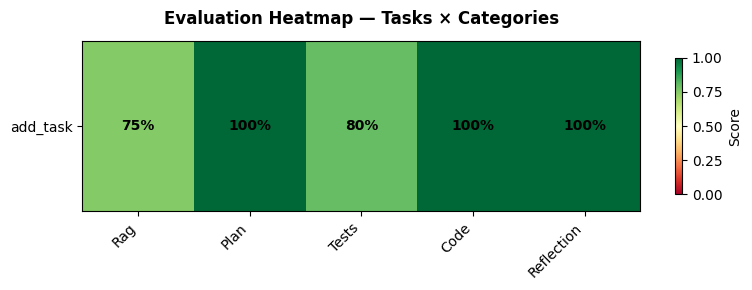

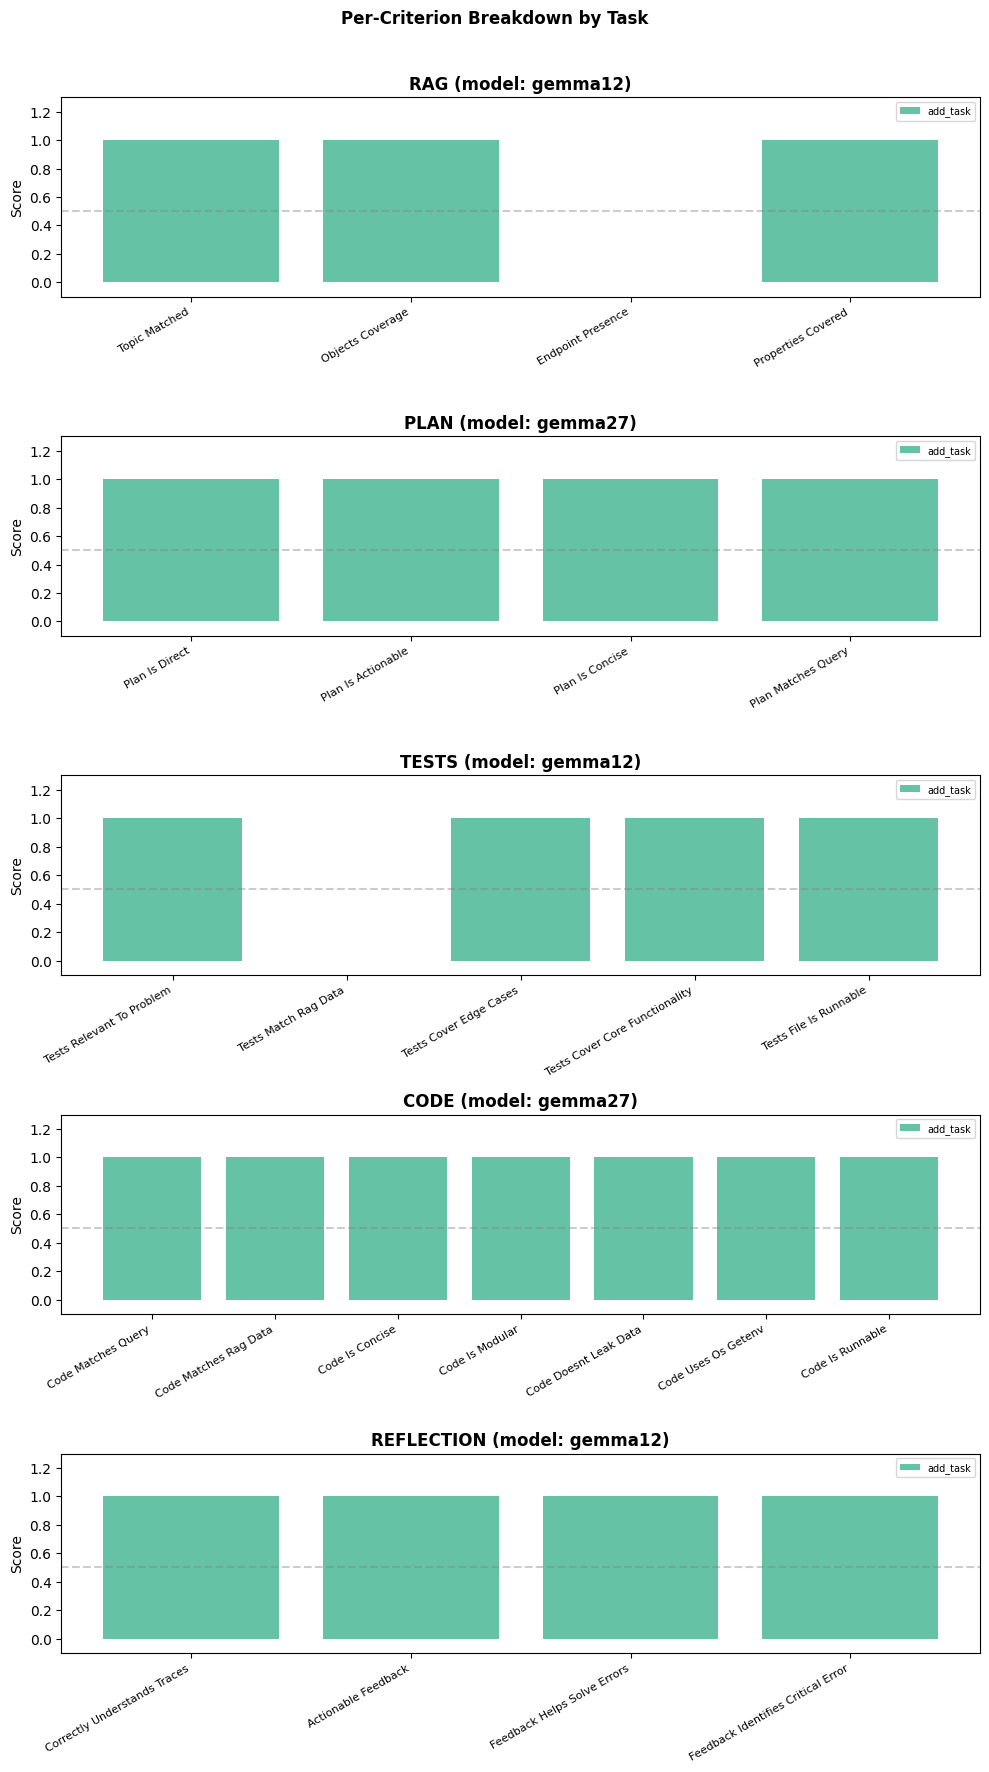

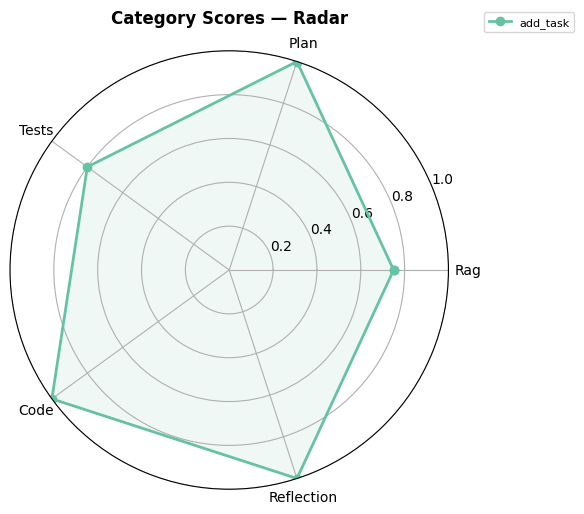


Task                        Plan  Tests   Code  Refl.  Overall
----------------------------------------------------------------------
add_task                   100%   80%  100%  100%     91%


In [50]:
# ── Visualize results ─────────────────────────────────────────────────────────
plot_evaluation_results(all_eval_results)

In [51]:
# ── Inspect detailed results per task ─────────────────────────────────────────
for task_id, result in all_eval_results.items():
    print(f"\n{'=' * 60}")
    print(f"TASK: {task_id}")
    print(f"Pipeline passed: {all_pipeline_artifacts[task_id].get('passed', False)}")
    print(f"Trials used: {all_pipeline_artifacts[task_id].get('total_trials', '?')}")
    
    for cat in EVAL_CRITERIA:
        cat_result = result.get(cat, {})
        print(f"\n  [{cat.upper()}] (judge: {EVAL_CRITERIA[cat]['model']})")
        for crit_key in EVAL_CRITERIA[cat]["criteria"]:
            entry = cat_result.get(crit_key, {})
            score = entry.get("score", "?") if isinstance(entry, dict) else "?"
            reason = entry.get("reason", "N/A") if isinstance(entry, dict) else "N/A"
            icon = "+" if score == 1 else "-" if score == 0 else "?"
            print(f"    [{icon}] {crit_key}: {reason}")
    
    s = result.get("summary", {})
    print(f"\n  Overall: {s.get('overall_score', 0):.0%}")


TASK: add_task
Pipeline passed: False
Trials used: 2

  [RAG] (judge: gemma12)
    [+] topic_matched: The document provides a detailed overview of the Notion Tasks database, directly addressing the user's need to interact with it.
    [+] objects_coverage: The document explicitly mentions 'Tasks' database, its ID, and the 'Project' database, covering the key Notion objects in the query.
    [-] endpoint_presence: The document lacks any mention of Notion API endpoints or HTTP methods, focusing solely on data source properties and considerations.
    [+] properties_covered: The document lists several relevant properties like 'Project/status', 'Project/priority', 'Status', 'Intensity', 'Difficulty', 'Progress', 'Urgency', 'Importance', 'Created', 'Project', 'Do Now', and 'Name', which are crucial for fulfilling the query.

  [PLAN] (judge: gemma27)
    [+] plan_is_direct: The plan immediately outlines the steps to add a task to Notion, directly addressing the user's query.
    [+] plan_i

In [52]:
import os
import pickle
from datetime import datetime

os.makedirs("evaluation_results", exist_ok=True)
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_file = f"evaluation_results/{timestamp}.pkl"

with open(results_file, "wb") as f:
    pickle.dump({"all_pipeline_artifacts": all_pipeline_artifacts, "all_eval_results": all_eval_results}, f)

print(f"\nResults saved to: {results_file}")


Results saved to: evaluation_results/2026-02-27_00-18-26.pkl
